## BNP Paribas Cardif
### Классификация претензий
1) Рассмотрение которых может быть ускорено, что приведет к более быстрым выплатам
2) Рассмотрение которых требуется дополнительная информация
### Бизнес-цель
Автоматически определять страховые претензии, которые можно обработать ускоренно на раннем этапе, чтобы сократить время выплат клиентам.

При этом важно минимизировать риск ошибочного ускорения заявок, требующих дополнительной проверки, сохраняя качество и надёжность процесса рассмотрения.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

train_path = '../data/bnp-paribas-cardif-claims-management/train.csv'
test_path = '../data/bnp-paribas-cardif-claims-management/test.csv'

df = pd.read_csv(train_path)
print(f"Train shape: {df.shape}")
print(df.head())

Train shape: (114321, 133)
   ID  target        v1        v2 v3        v4         v5        v6        v7  \
0   3       1  1.335739  8.727474  C  3.921026   7.915266  2.599278  3.176895   
1   4       1       NaN       NaN  C       NaN   9.191265       NaN       NaN   
2   5       1  0.943877  5.310079  C  4.410969   5.326159  3.979592  3.928571   
3   6       1  0.797415  8.304757  C  4.225930  11.627438  2.097700  1.987549   
4   8       1       NaN       NaN  C       NaN        NaN       NaN       NaN   

         v8         v9       v10        v11       v12       v13        v14  \
0  0.012941   9.999999  0.503281  16.434108  6.085711  2.866830  11.636387   
1  2.301630        NaN  1.312910        NaN  6.507647       NaN  11.636386   
2  0.019645  12.666667  0.765864  14.756098  6.384670  2.505589   9.603542   
3  0.171947   8.965516  6.542669  16.347483  9.646653  3.903302  14.094723   
4       NaN        NaN  1.050328        NaN  6.320087       NaN  10.991098   

        v15      

target
1    0.761199
0    0.238801
Name: proportion, dtype: float64


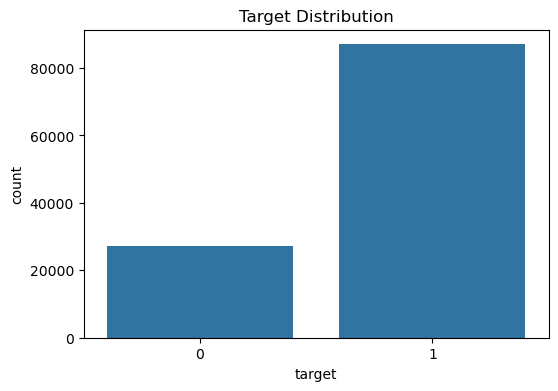

In [53]:
print(df['target'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

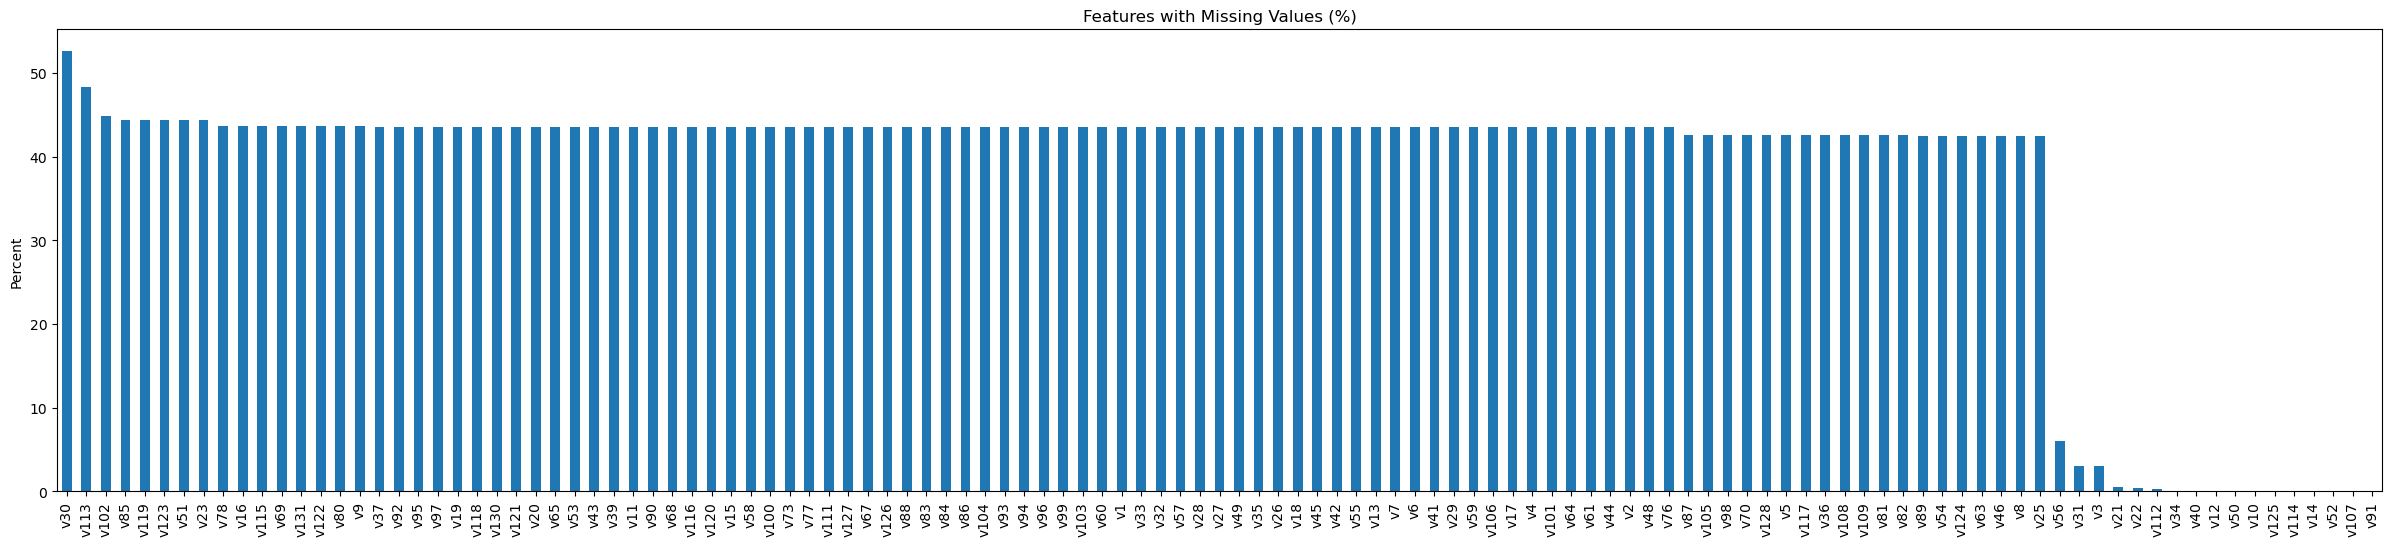

In [54]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_percent = missing / len(df) * 100
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(30, 6))
missing_percent.head(len(missing_percent)).plot(kind='bar')
plt.title('Features with Missing Values (%)')
plt.ylabel('Percent')
plt.show()

In [55]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'ID' in numerical_cols: numerical_cols.remove('ID')
if 'target' in numerical_cols: numerical_cols.remove('target')

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 112
Categorical features: 19


In [56]:
df[categorical_cols].head()

,v3,v22,v24,v30,v31,v47,v52,v56,v66,v71,v74,v75,v79,v91,v107,v110,v112,v113,v125
0,C,XDX,C,C,A,C,G,DI,C,F,B,D,E,A,E,B,O,NaN,AU
1,C,GUV,C,C,A,E,G,DY,A,F,B,D,D,B,B,A,U,G,AF
2,C,FQ,E,NaN,A,C,F,AS,A,B,B,B,E,G,C,B,S,NaN,AE
3,C,ACUE,D,C,B,C,H,BW,A,F,B,D,B,B,B,B,J,NaN,CJ
4,C,HIT,E,NaN,A,I,H,NaN,C,F,B,D,C,G,C,A,T,G,Z


In [57]:
from IPython.display import display

print("Numerical Features Statistics:")
display(df[numerical_cols].describe().T)

print("\nCategorical Features Statistics:")
display(df[categorical_cols].describe().T)

Numerical Features Statistics:


,count,mean,std,min,25%,50%,75%,max
v1,64489.0,1.630686,1.082813,-9.996497e-07,0.913580,1.469550,2.136128,20.000001
v2,64525.0,7.464411,2.961676,-9.817614e-07,5.316428,7.023803,9.465497,20.000000
v4,64525.0,4.145098,1.148263,-6.475929e-07,3.487398,4.205991,4.833250,20.000000
v5,65697.0,8.742359,2.036018,-5.287068e-07,7.605918,8.670867,9.771353,20.000000
v6,64489.0,2.436402,0.599965,-9.055091e-07,2.065064,2.412790,2.775285,20.000001
...,...,...,...,...,...,...,...,...
v127,64489.0,3.239542,1.625988,-9.223798e-07,2.101900,2.963620,4.108146,19.999999
v128,65697.0,2.030373,1.074232,8.197812e-07,1.393830,1.798436,2.390158,20.000000
v129,114321.0,0.310144,0.693262,0.000000e+00,0.000000,0.000000,0.000000,11.000000
v130,64478.0,1.925763,1.264497,-9.901257e-07,1.106172,1.560138,2.332425,20.000000



Categorical Features Statistics:


,count,unique,top,freq
v3,110864,3,C,110584
v22,113821,18210,AGDF,2386
v24,114321,5,E,55177
v30,54211,7,C,32178
v31,110864,3,A,88347
v47,114321,10,C,55425
v52,114318,12,J,11103
v56,107439,122,BW,11351
v66,114321,3,A,70353
v71,114321,9,F,75094


Plotting 28 features...
Processing feature 1/28: v1
Processing feature 6/28: v7
Processing feature 11/28: v12
Processing feature 16/28: v17
Processing feature 21/28: v23
Processing feature 26/28: v29


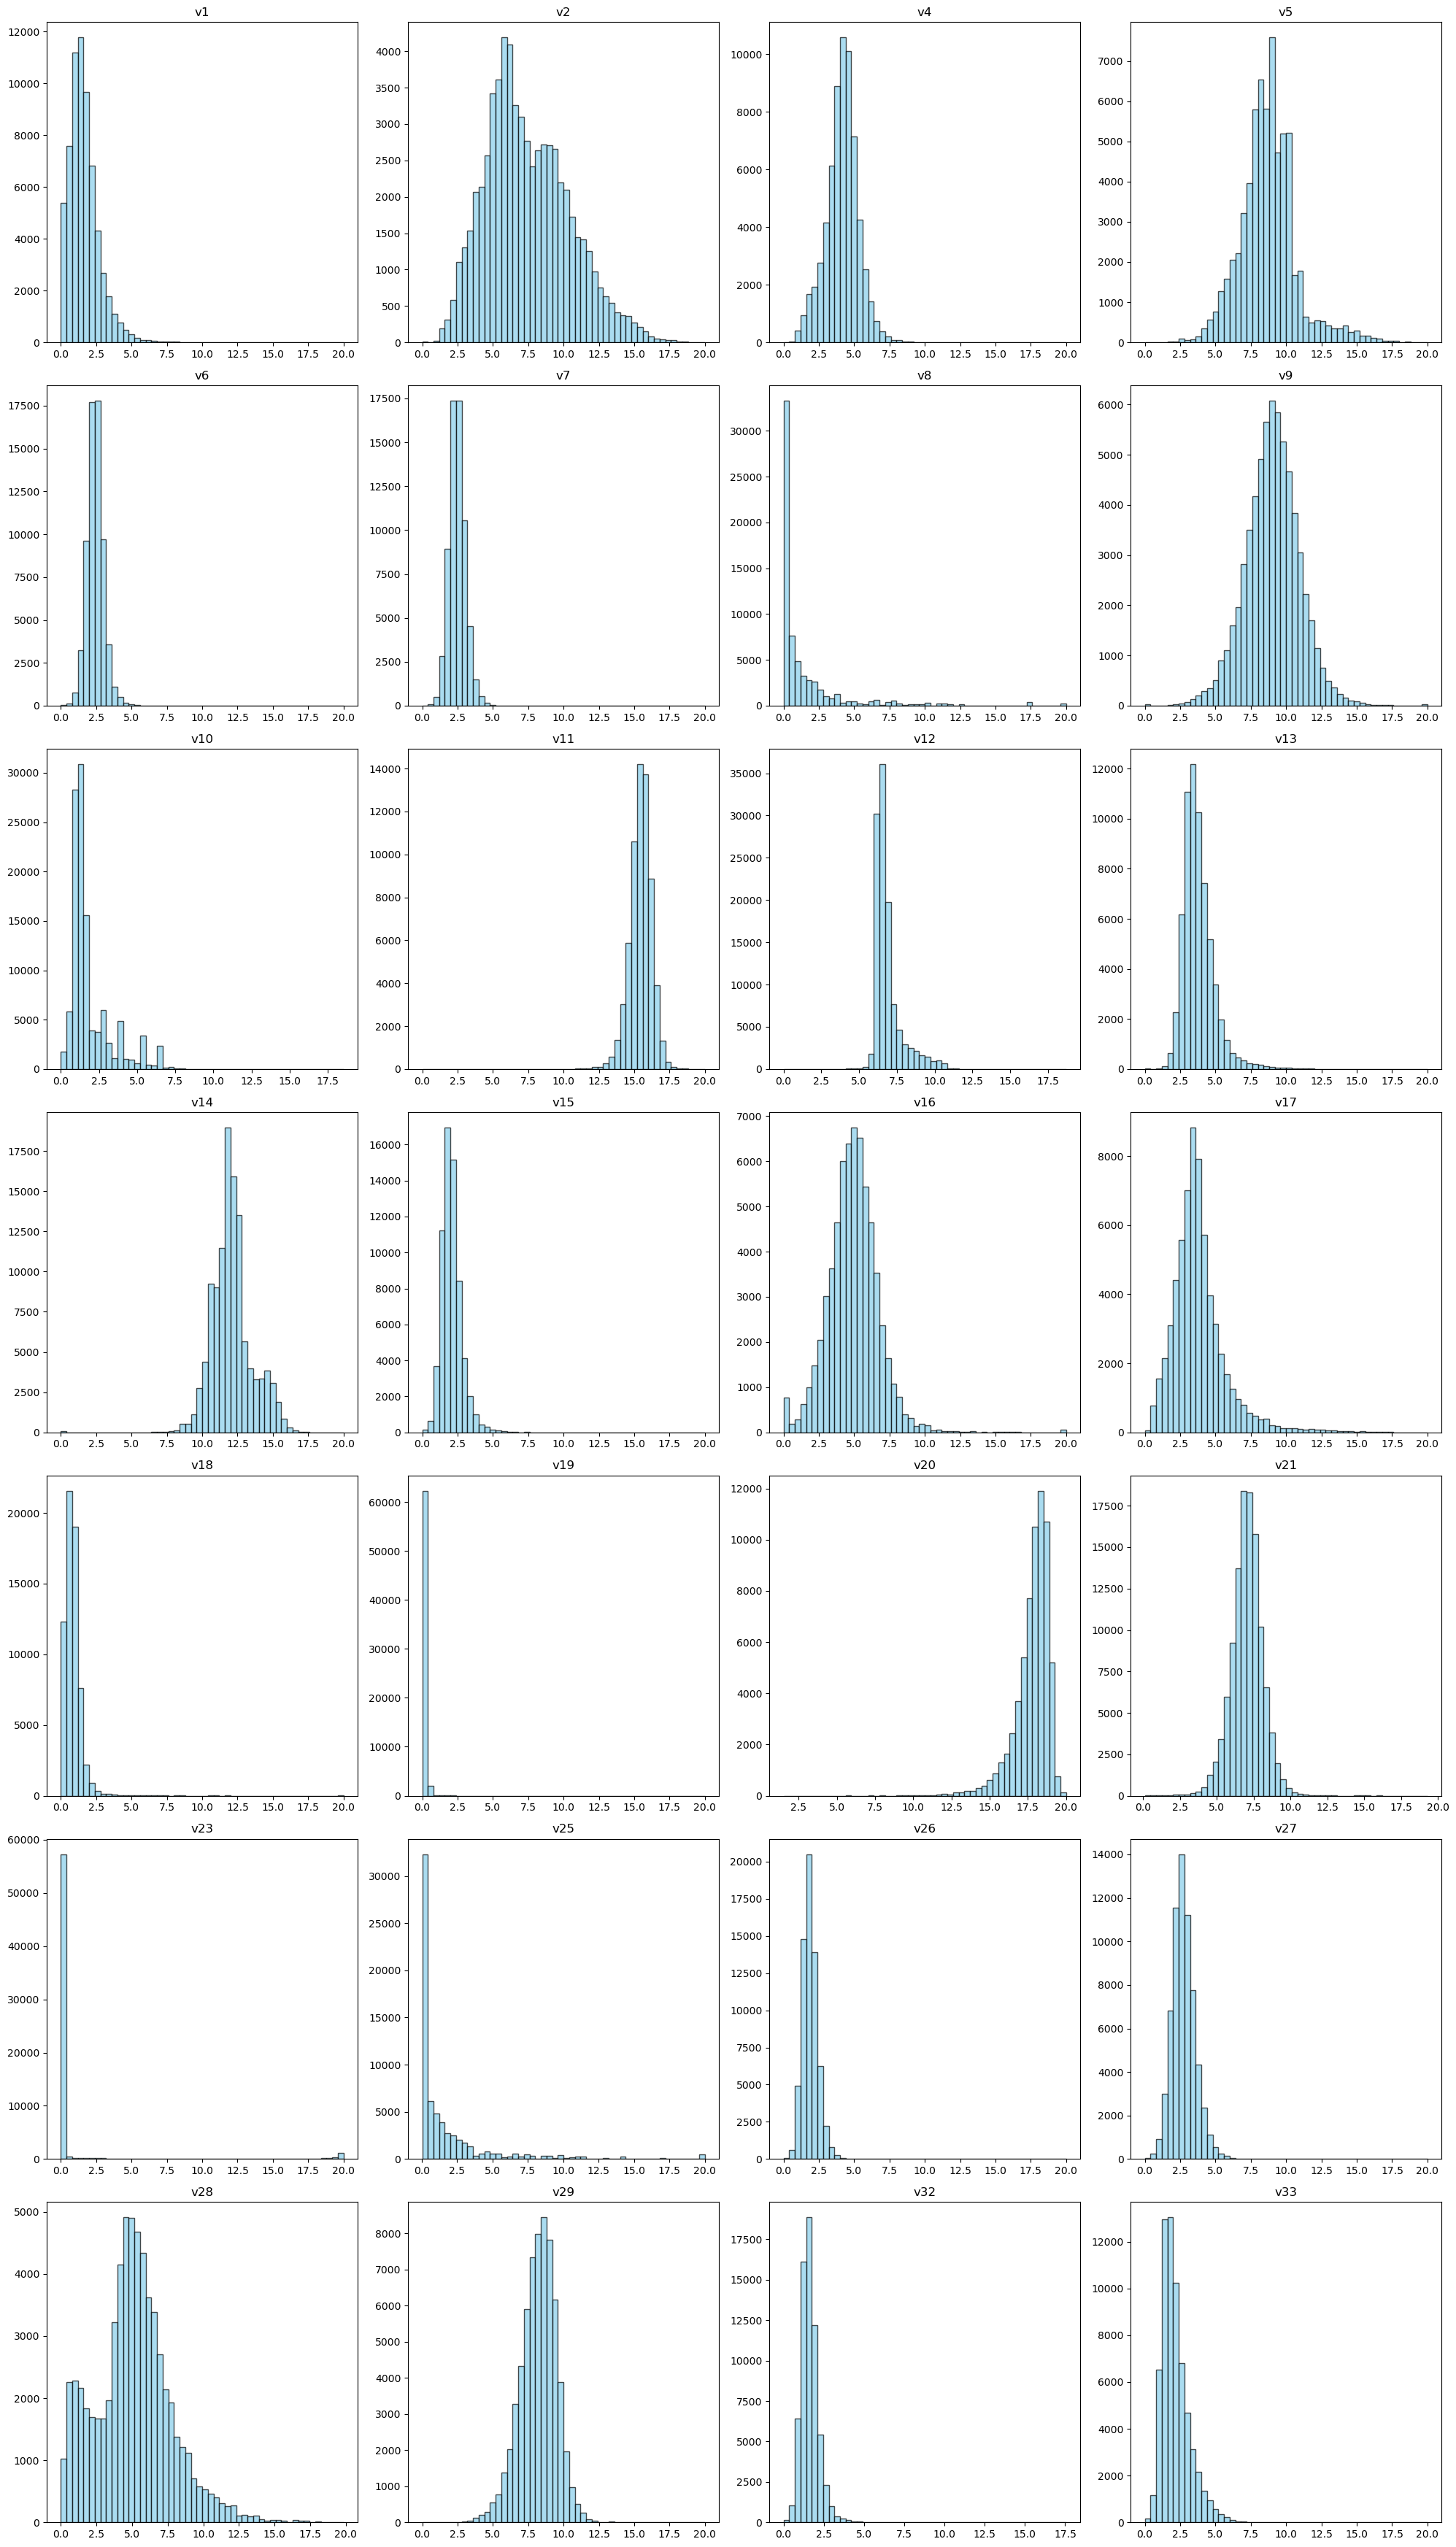

In [58]:
import math

subset_cols = numerical_cols[0:28]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v34
Processing feature 6/28: v39
Processing feature 11/28: v44
Processing feature 16/28: v50
Processing feature 21/28: v57
Processing feature 26/28: v62


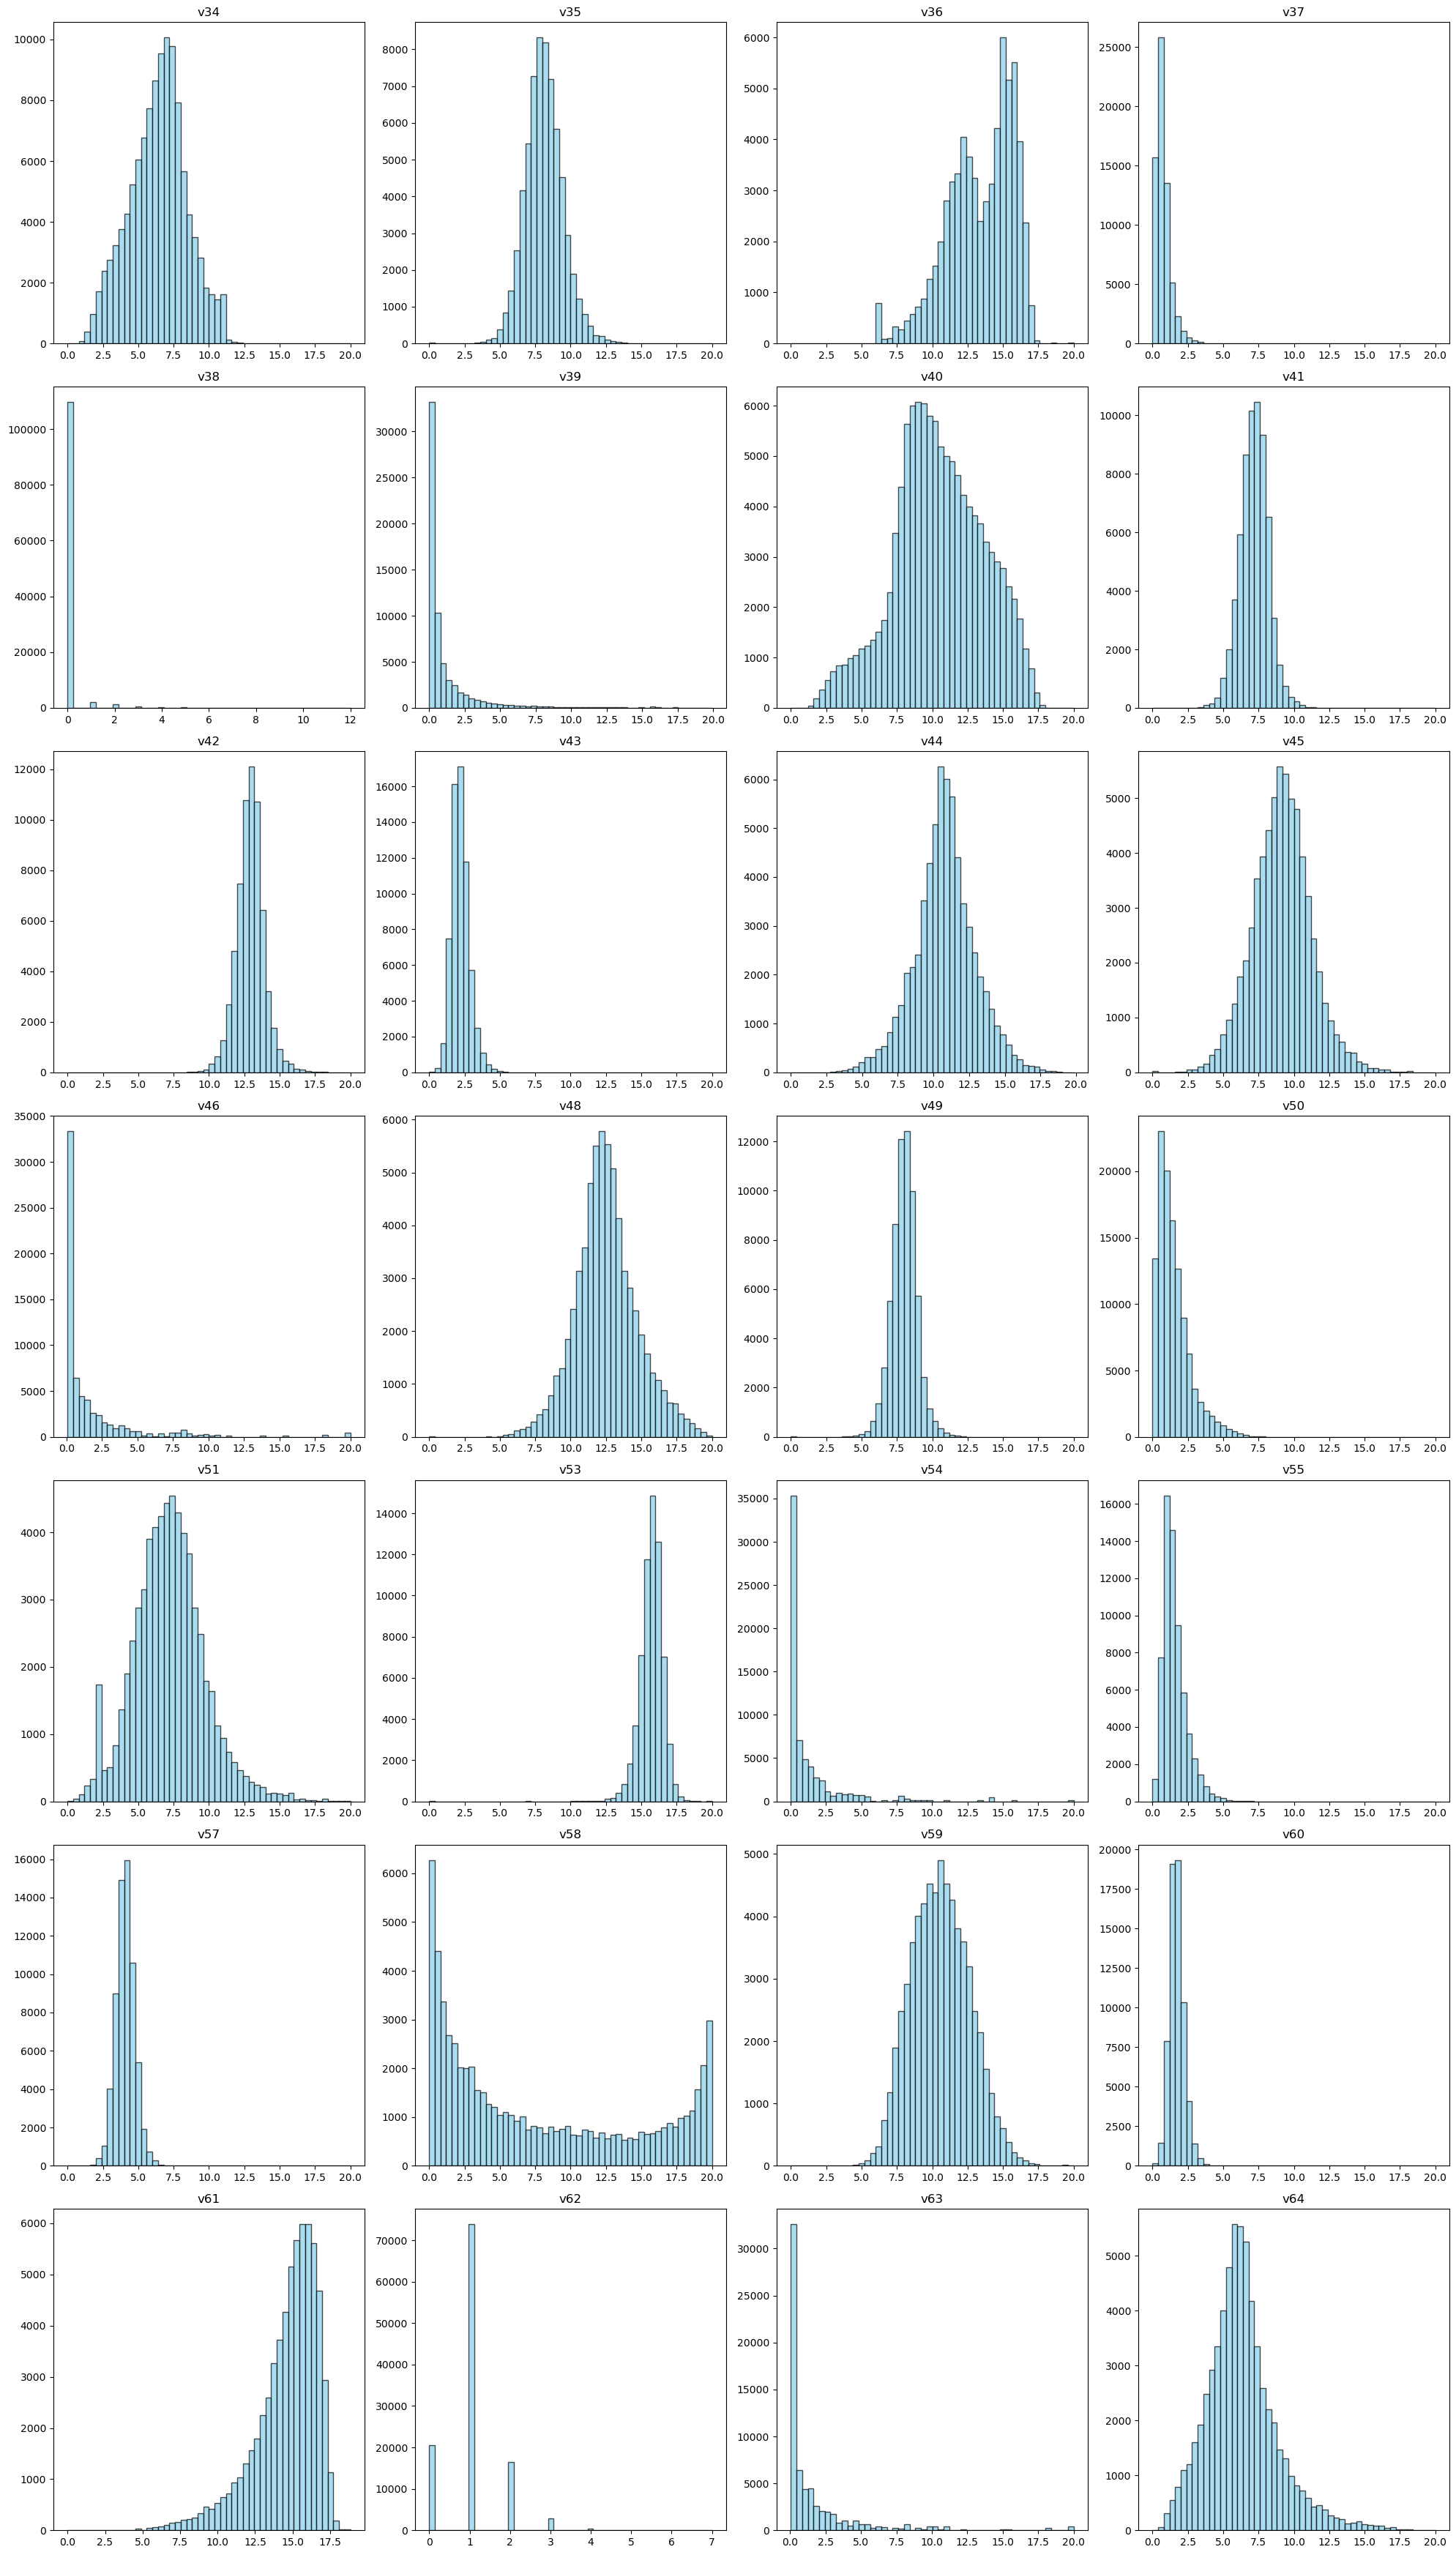

In [59]:
subset_cols = numerical_cols[28:56]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v65
Processing feature 6/28: v72
Processing feature 11/28: v80
Processing feature 16/28: v85
Processing feature 21/28: v90
Processing feature 26/28: v96


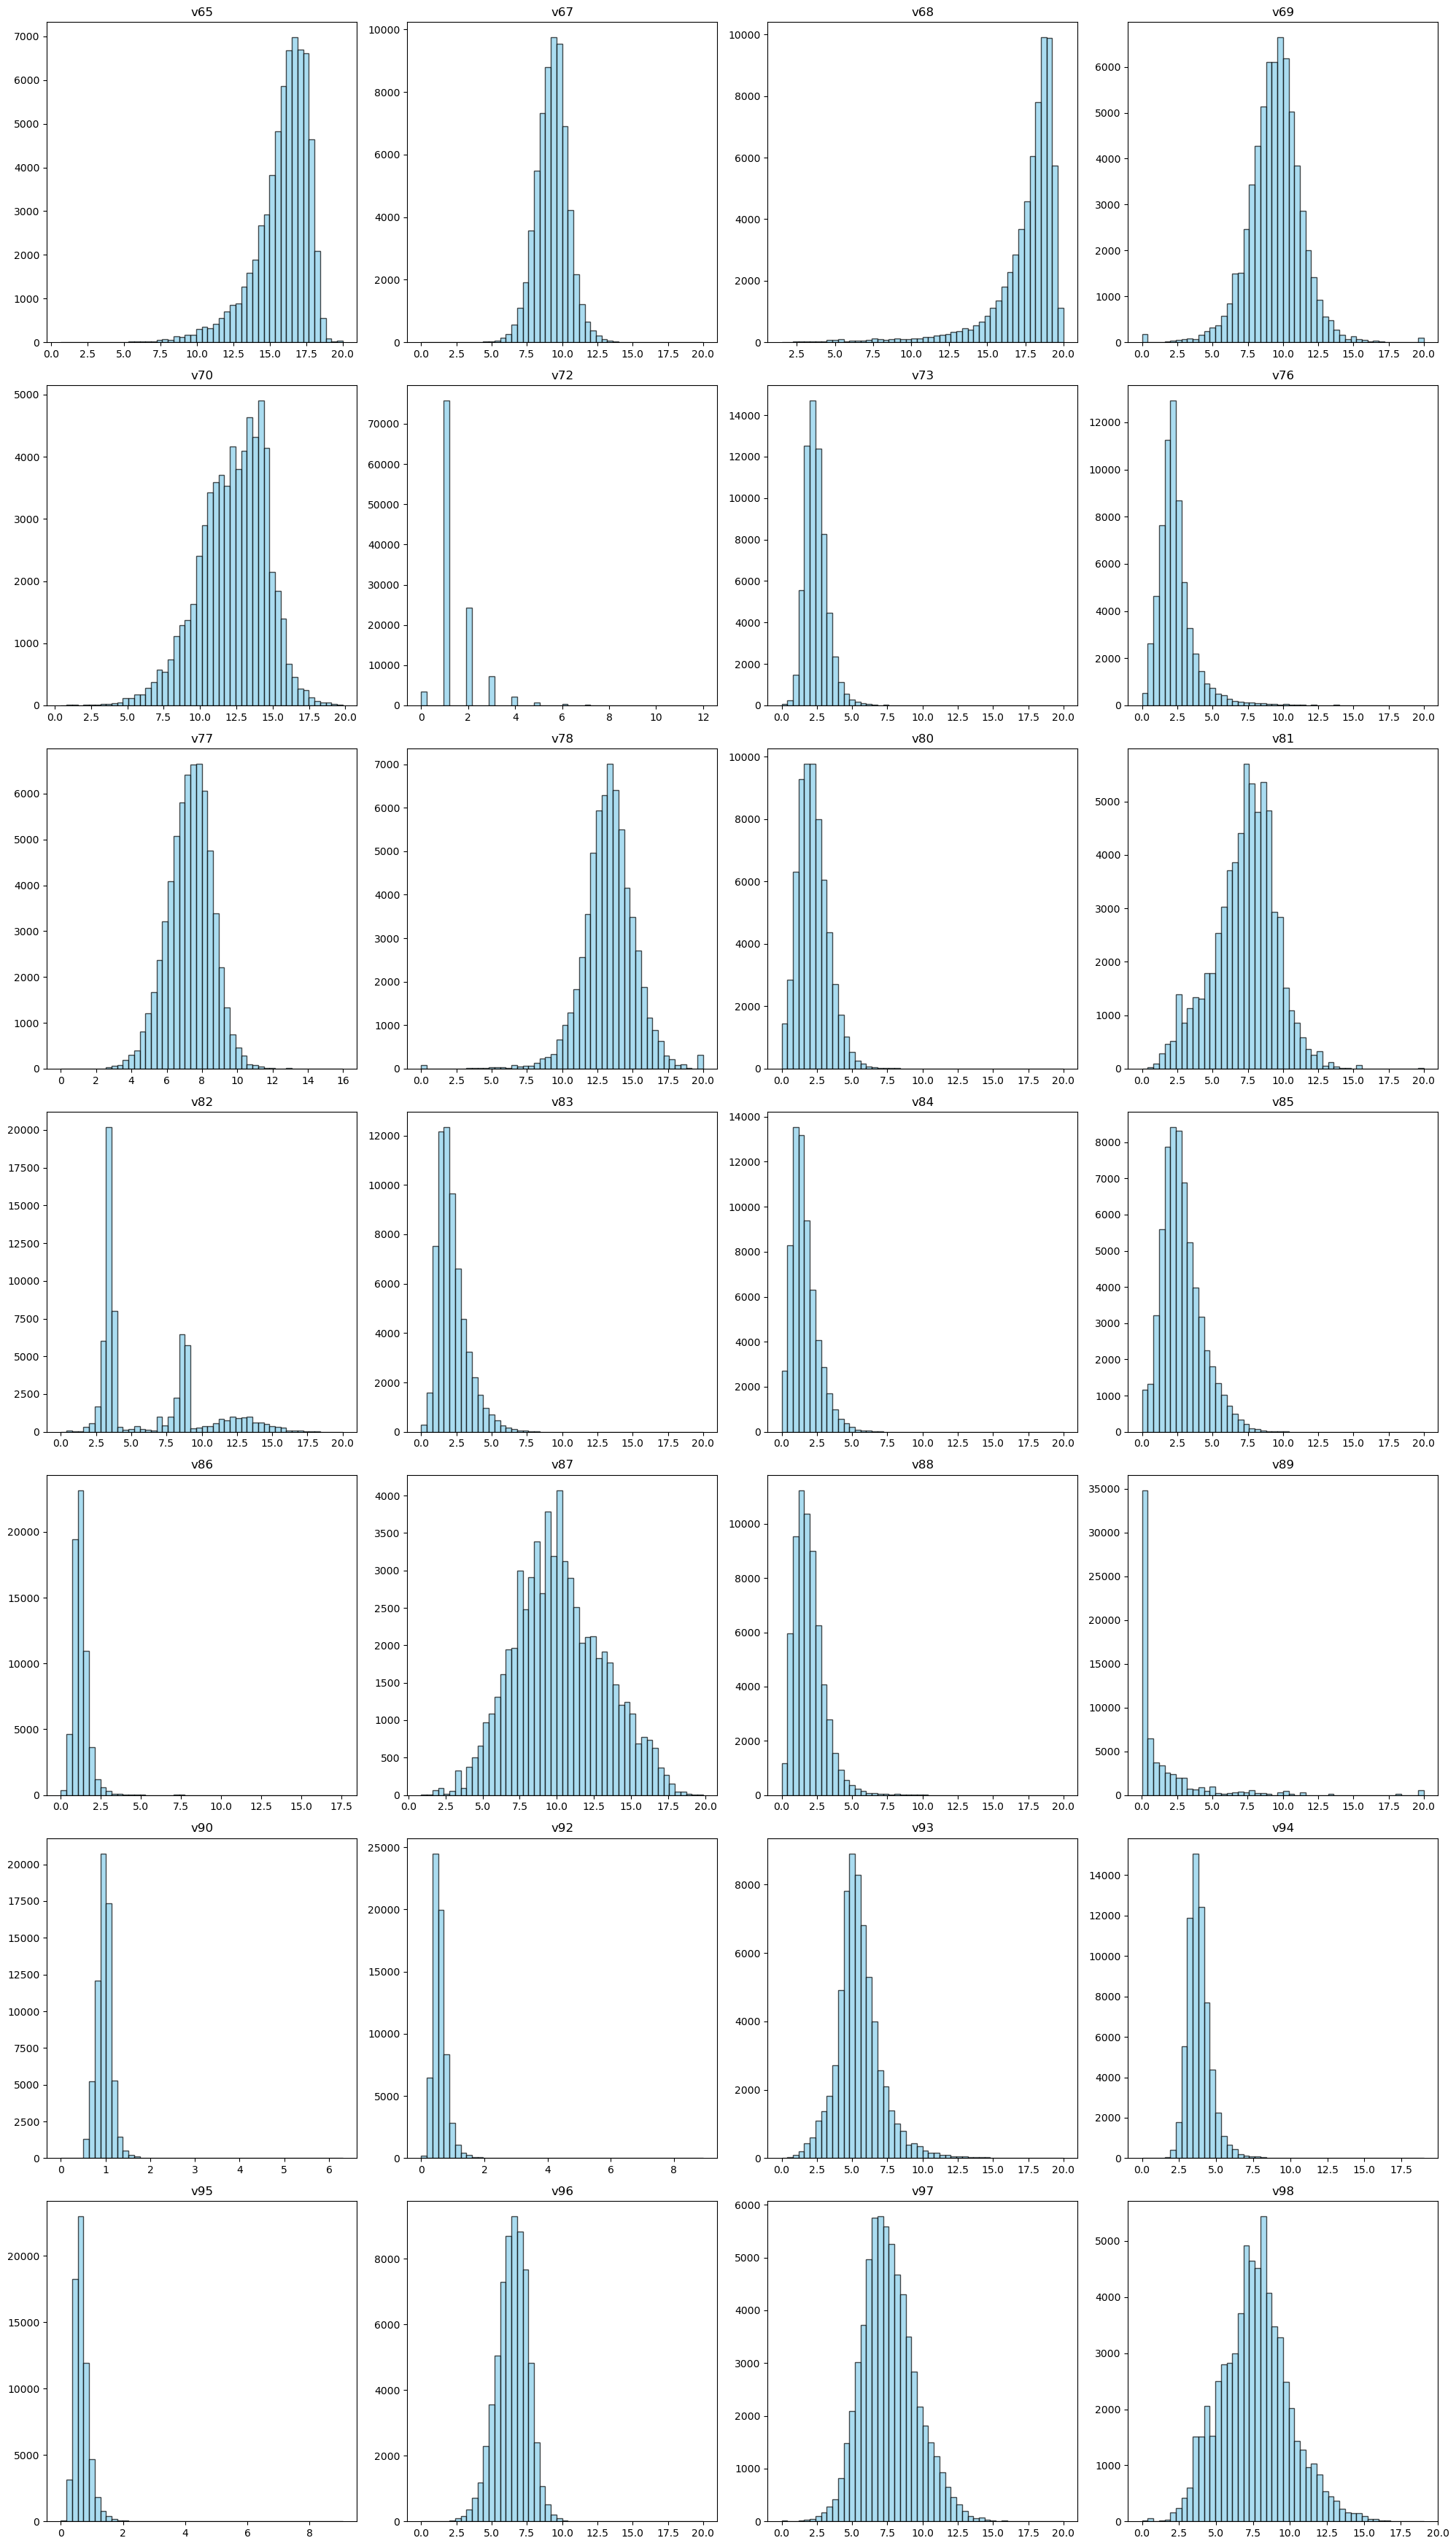

In [60]:
subset_cols = numerical_cols[56:84]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v99
Processing feature 6/28: v104
Processing feature 11/28: v111
Processing feature 16/28: v118
Processing feature 21/28: v123
Processing feature 26/28: v129


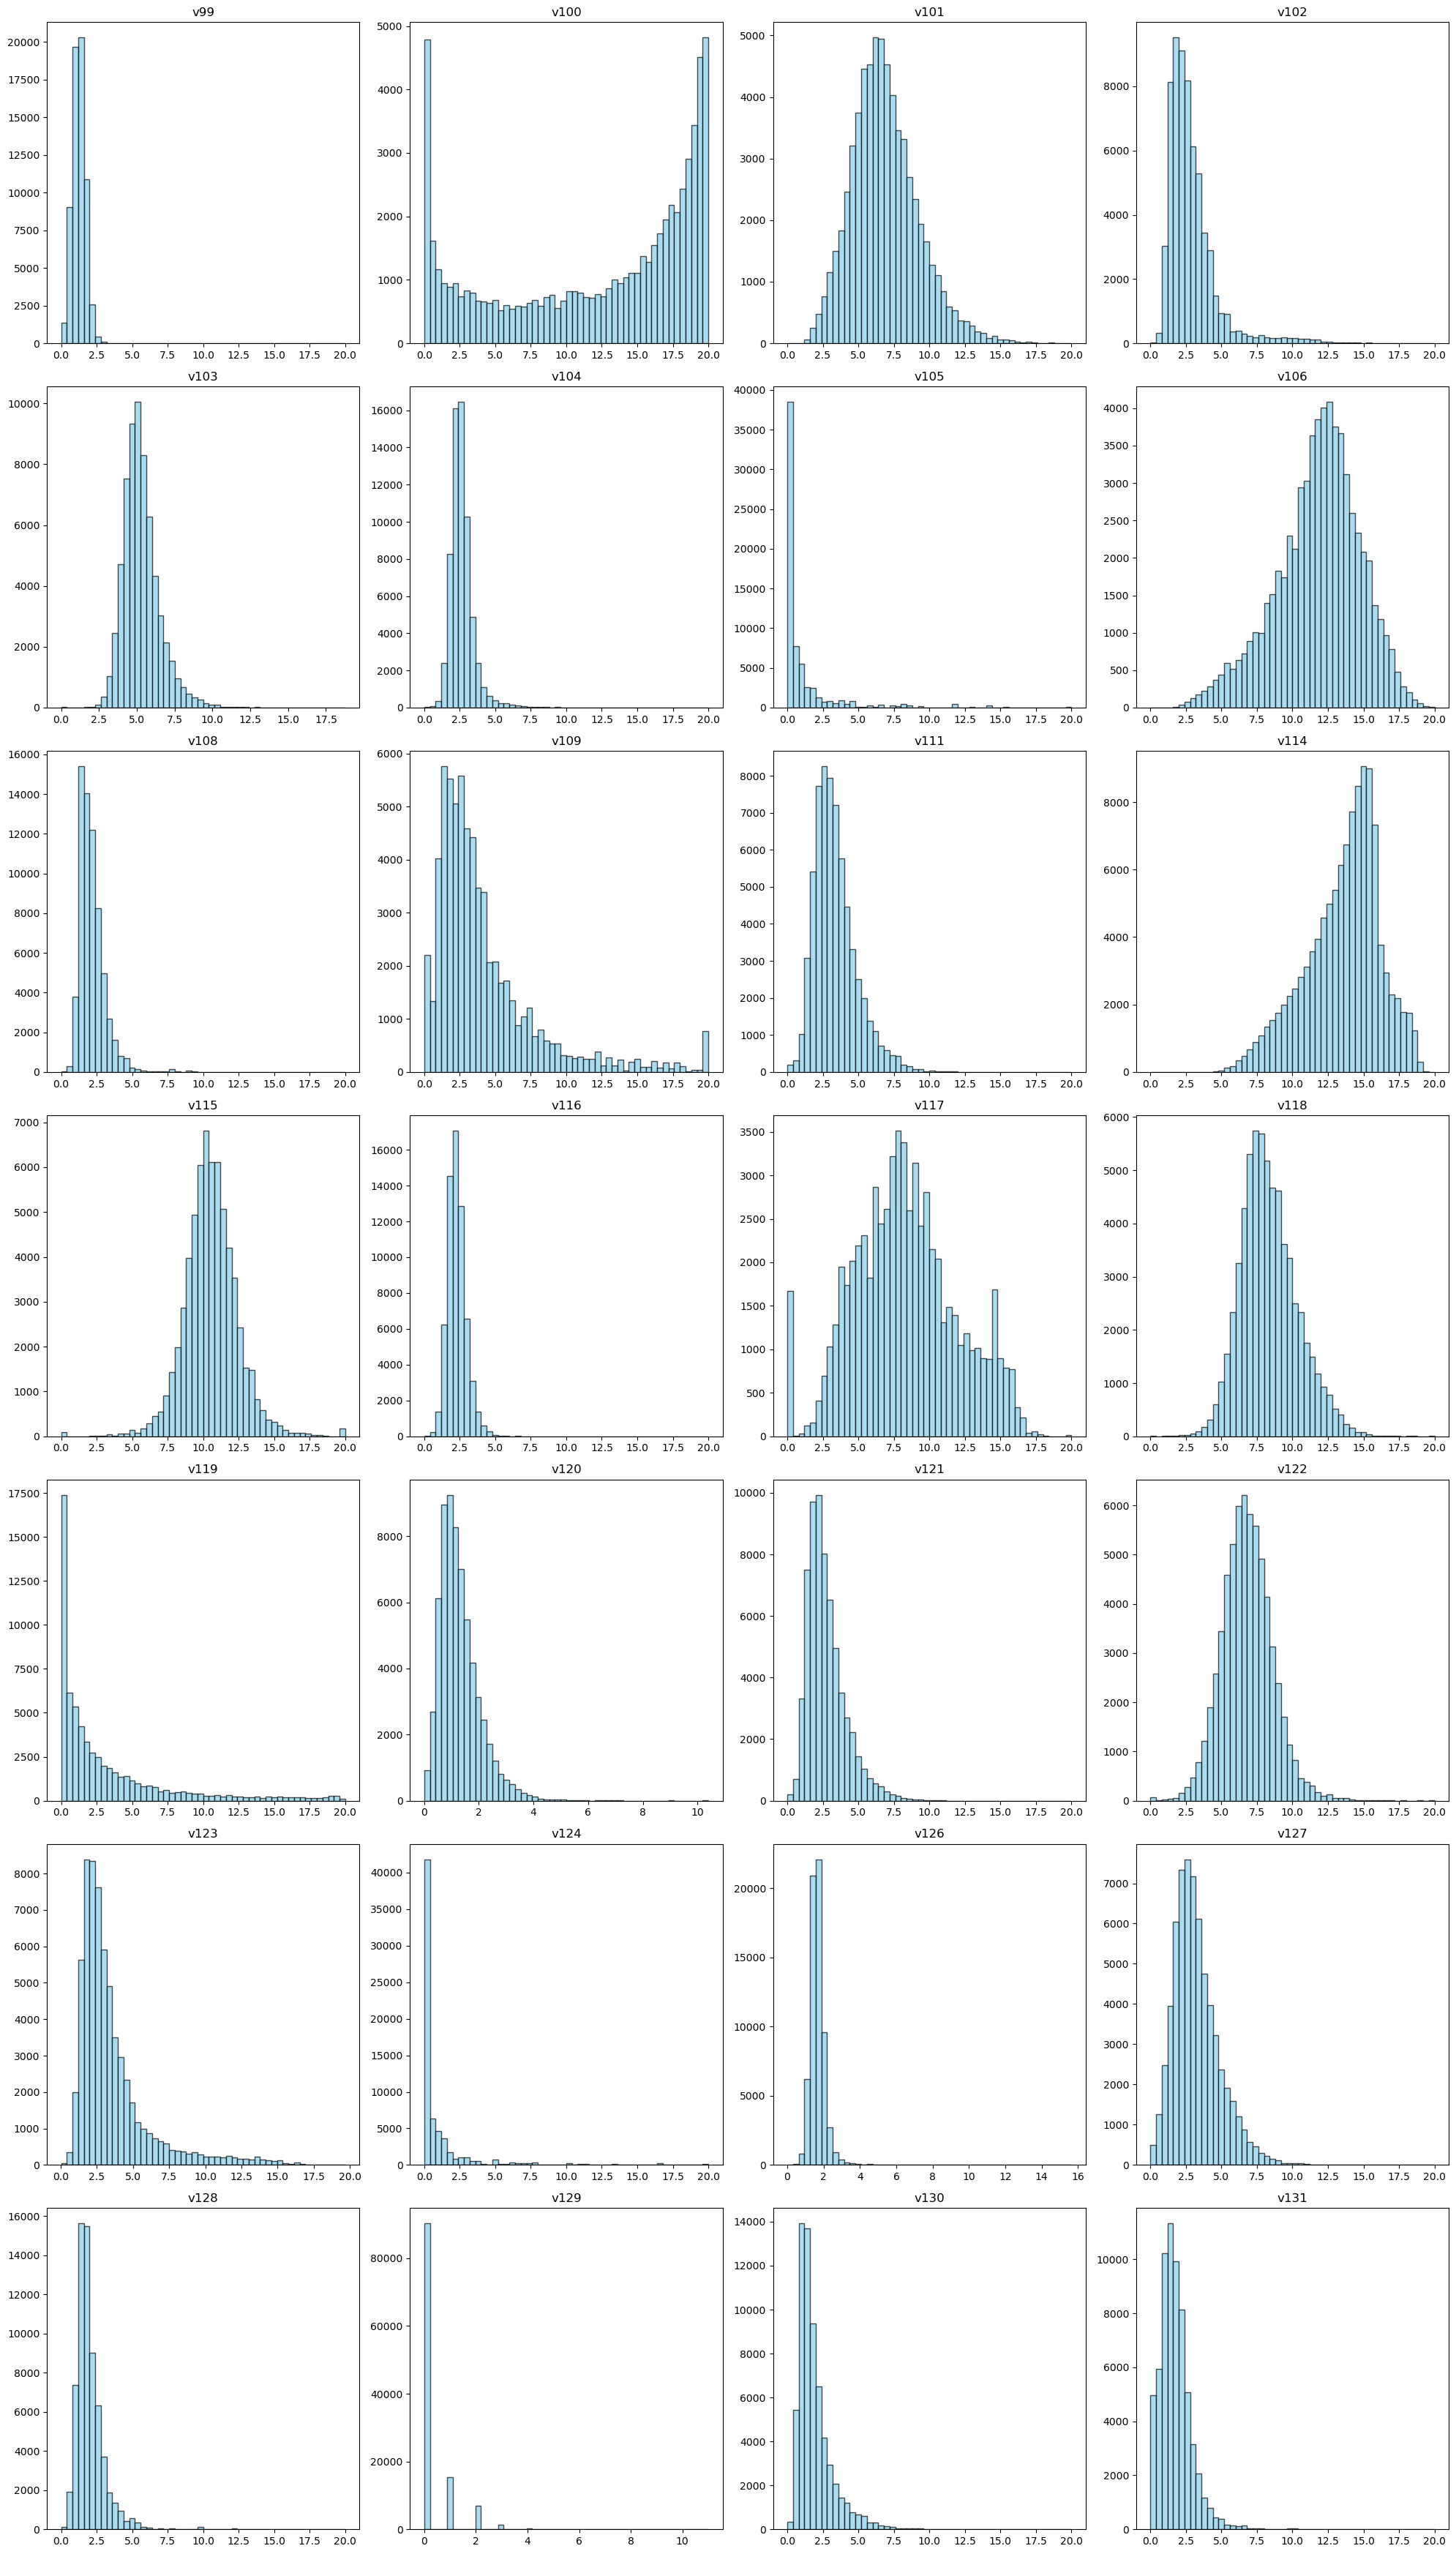

In [61]:
subset_cols = numerical_cols[84:112]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    data = df[col].dropna()
    # Use simple histogram without KDE for speed
    axes[i].hist(data, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [62]:
df['v129'].value_counts()

v129
0     90247
1     15313
2      6889
3      1373
4       357
5        83
6        45
11        8
7         3
8         3
Name: count, dtype: int64

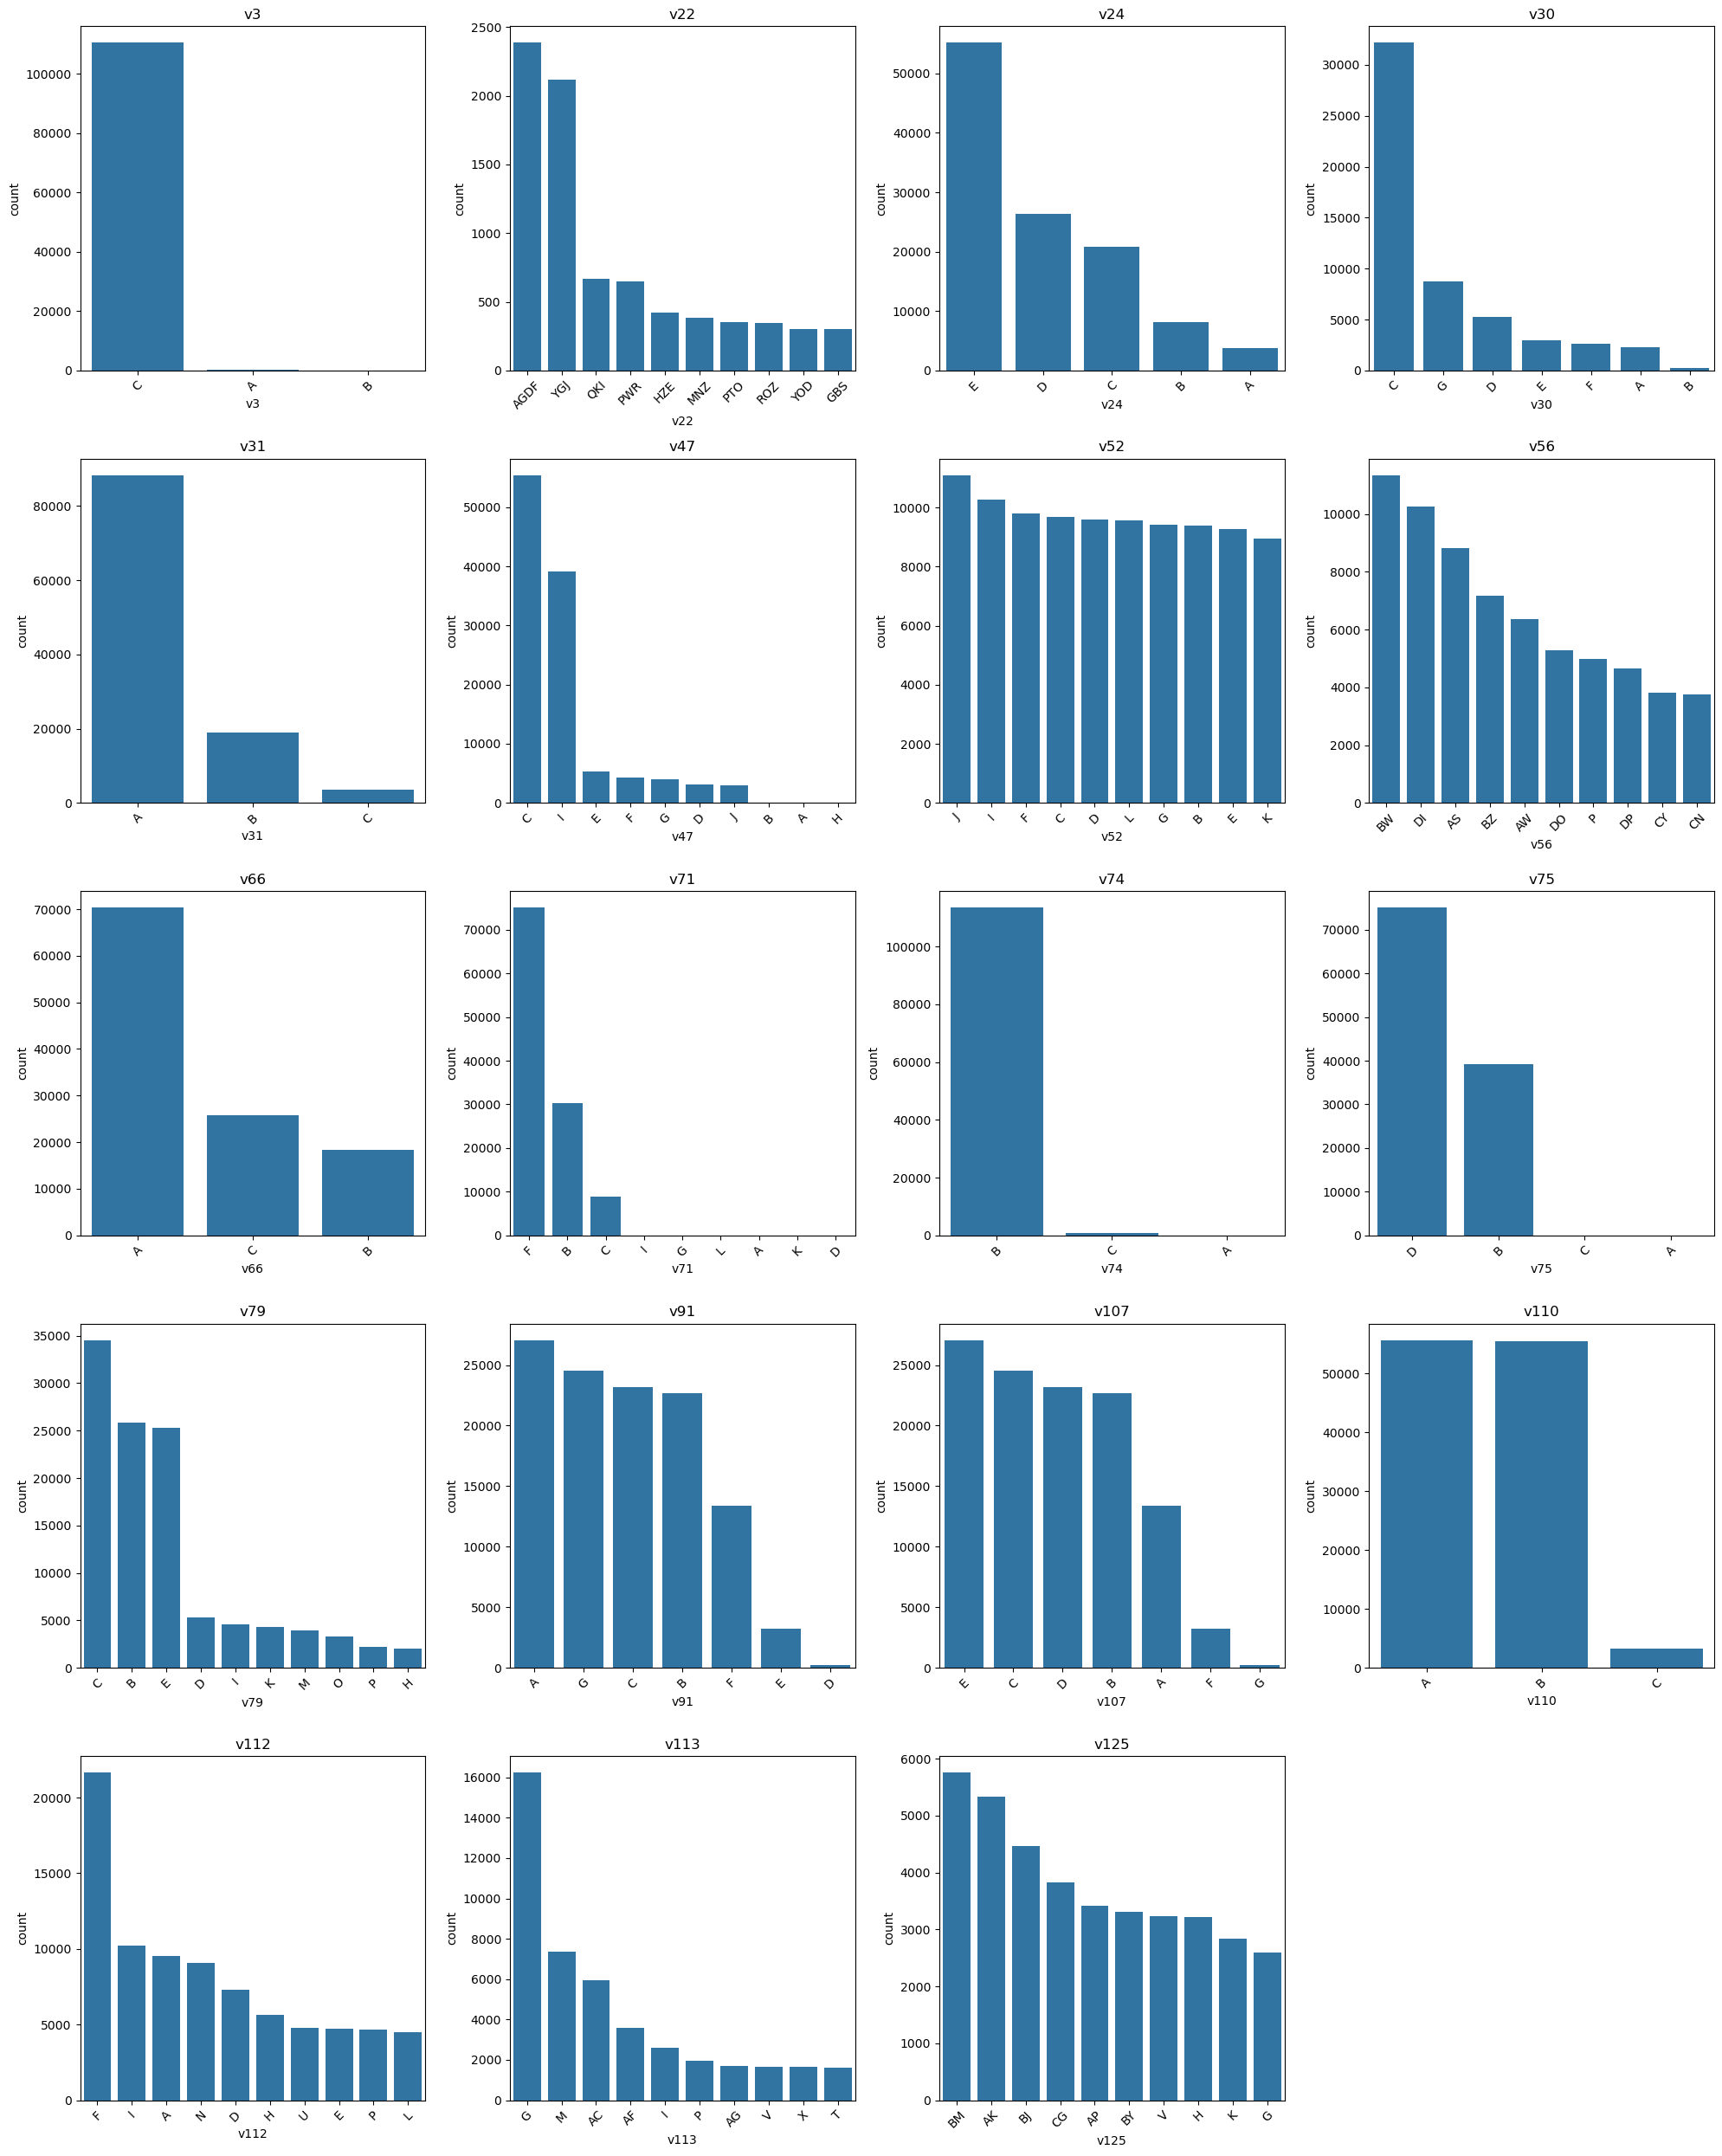

In [63]:
import math

n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    top_cats = df[col].value_counts().index[:10]
    sns.countplot(x=col, data=df[df[col].isin(top_cats)], ax=axes[i], order=top_cats)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v1
Processing feature 6/28: v7
Processing feature 11/28: v12
Processing feature 16/28: v17
Processing feature 21/28: v23
Processing feature 26/28: v29


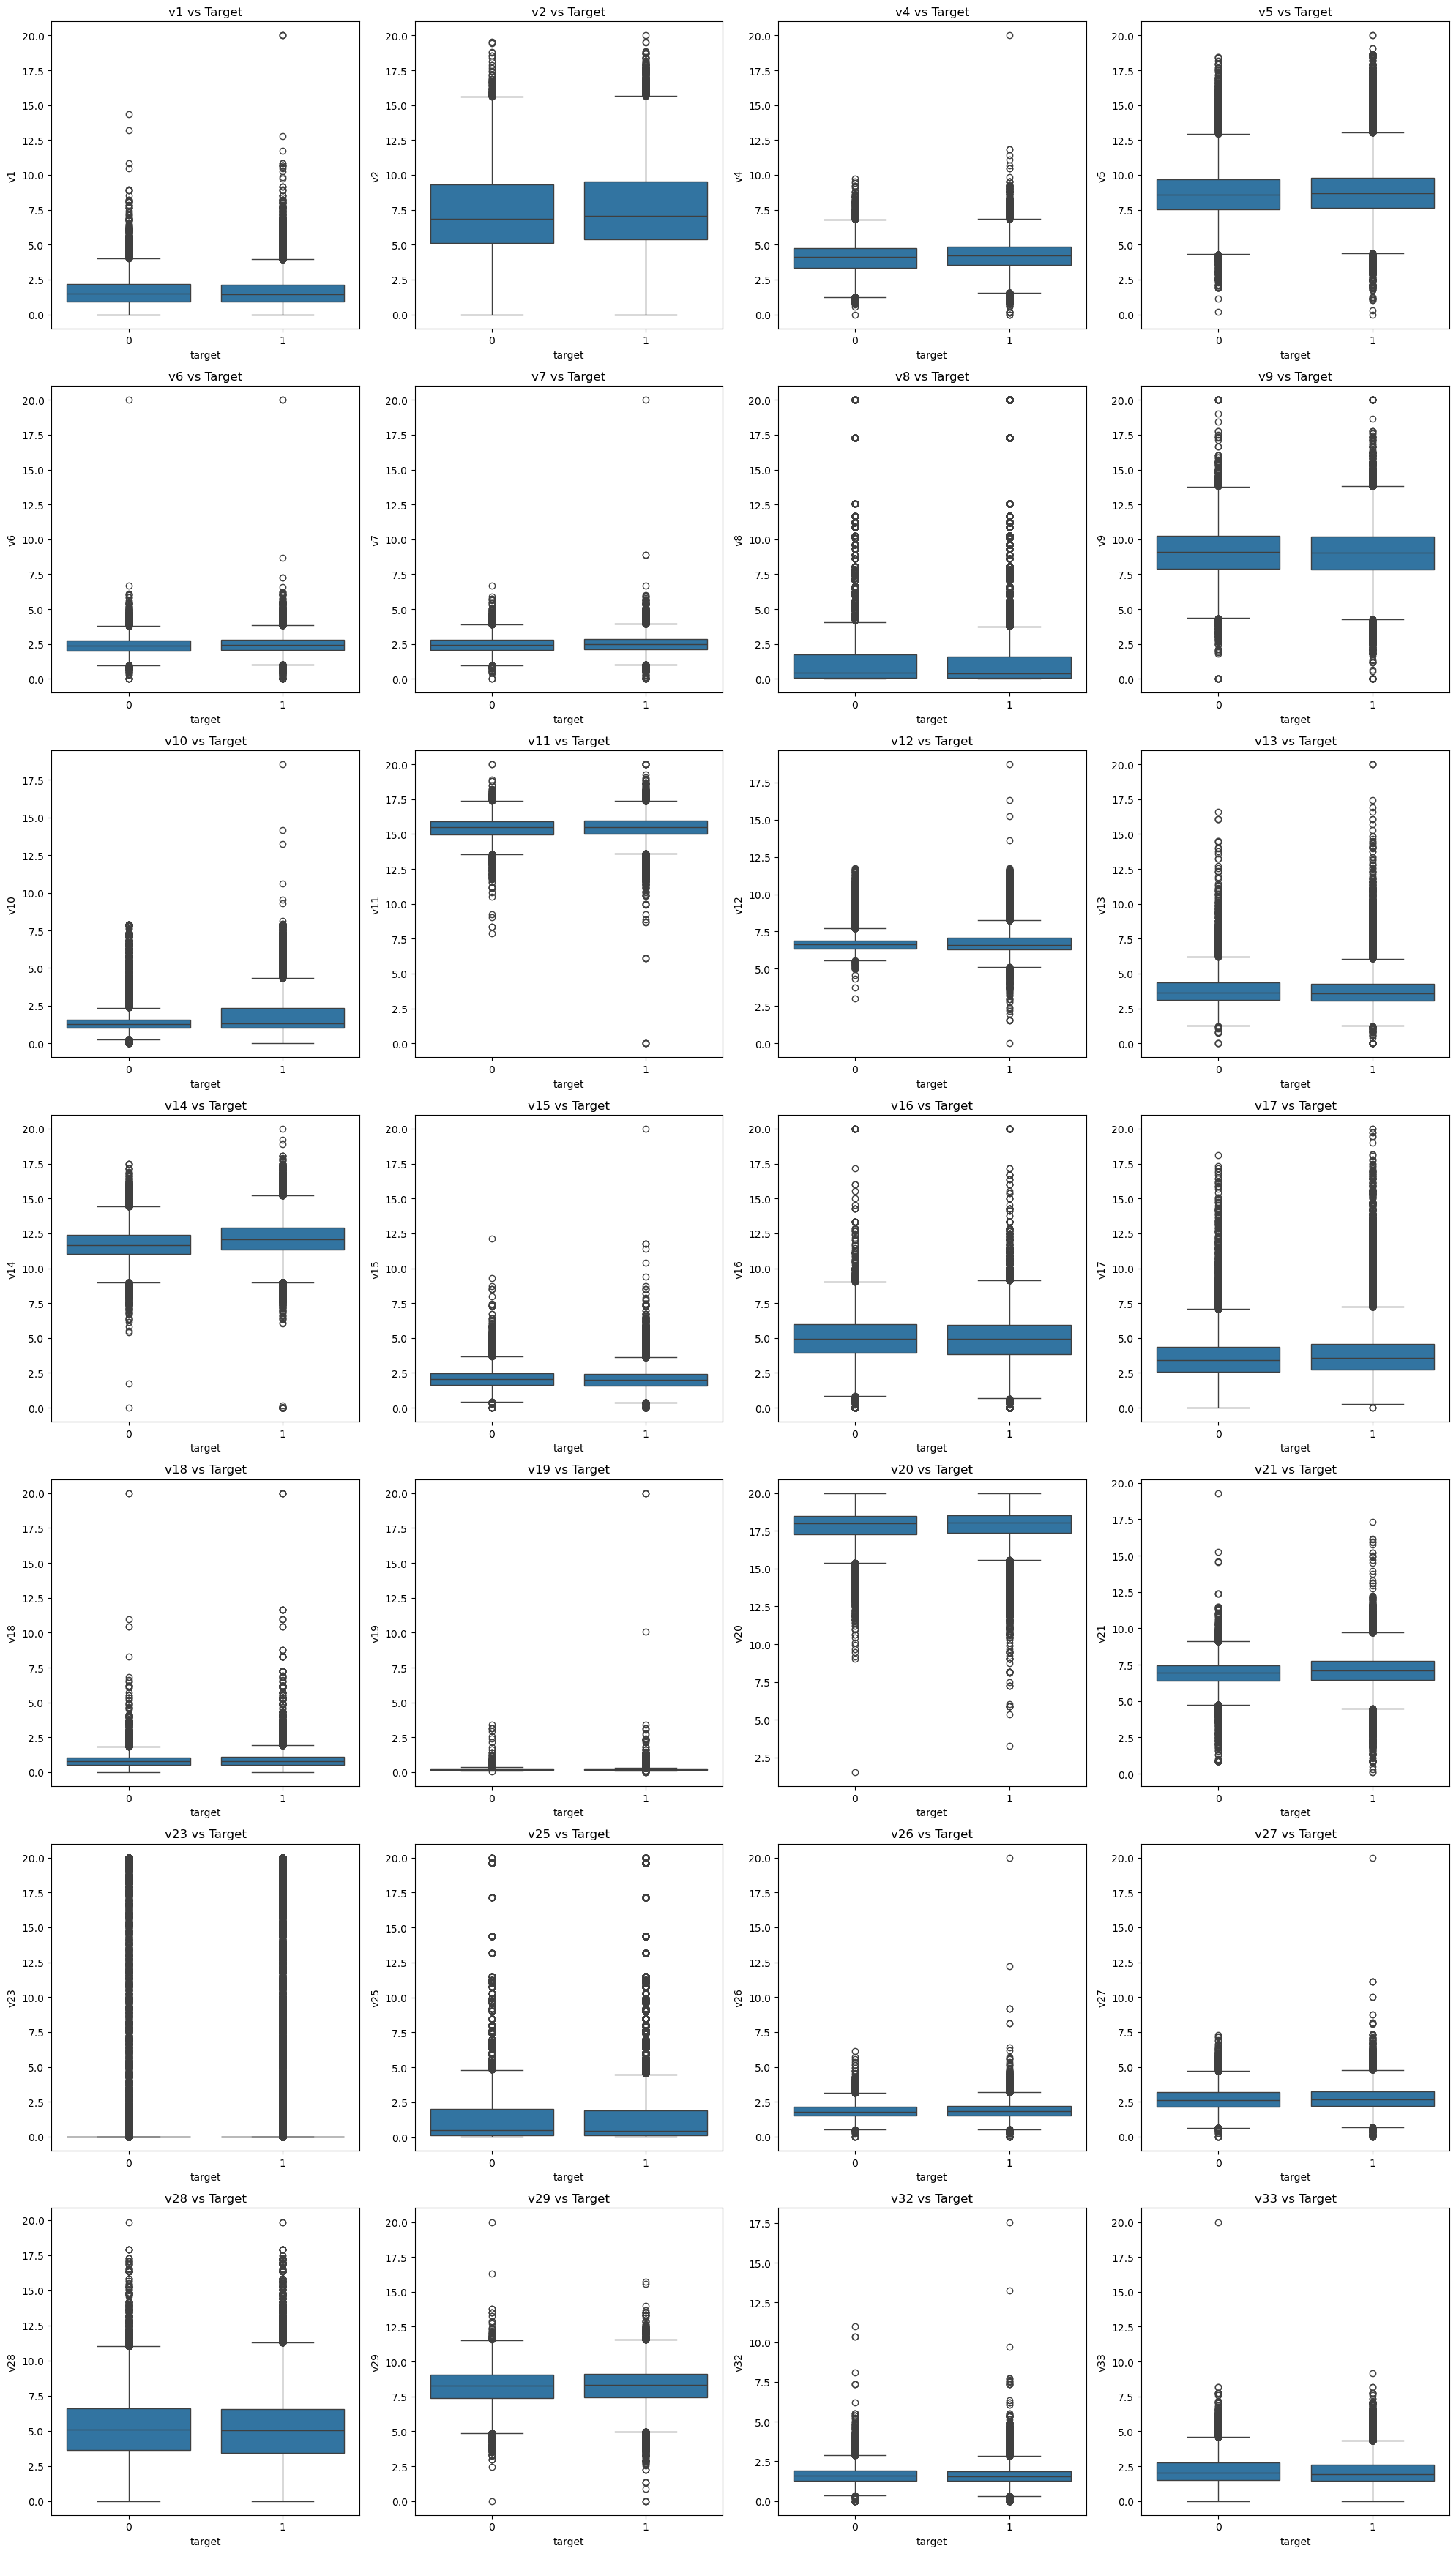

In [64]:
subset_cols = numerical_cols[0:28]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    try:
        sns.boxplot(x='target', y=col, data=df, ax=axes[i])
        axes[i].set_title(f'{col} vs Target')
    except Exception as e:
        print(f'Error plotting {col}: {e}')
        axes[i].text(0.5, 0.5, 'Error', ha='center', va='center')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v34
Processing feature 6/28: v39
Processing feature 11/28: v44
Processing feature 16/28: v50
Processing feature 21/28: v57
Processing feature 26/28: v62


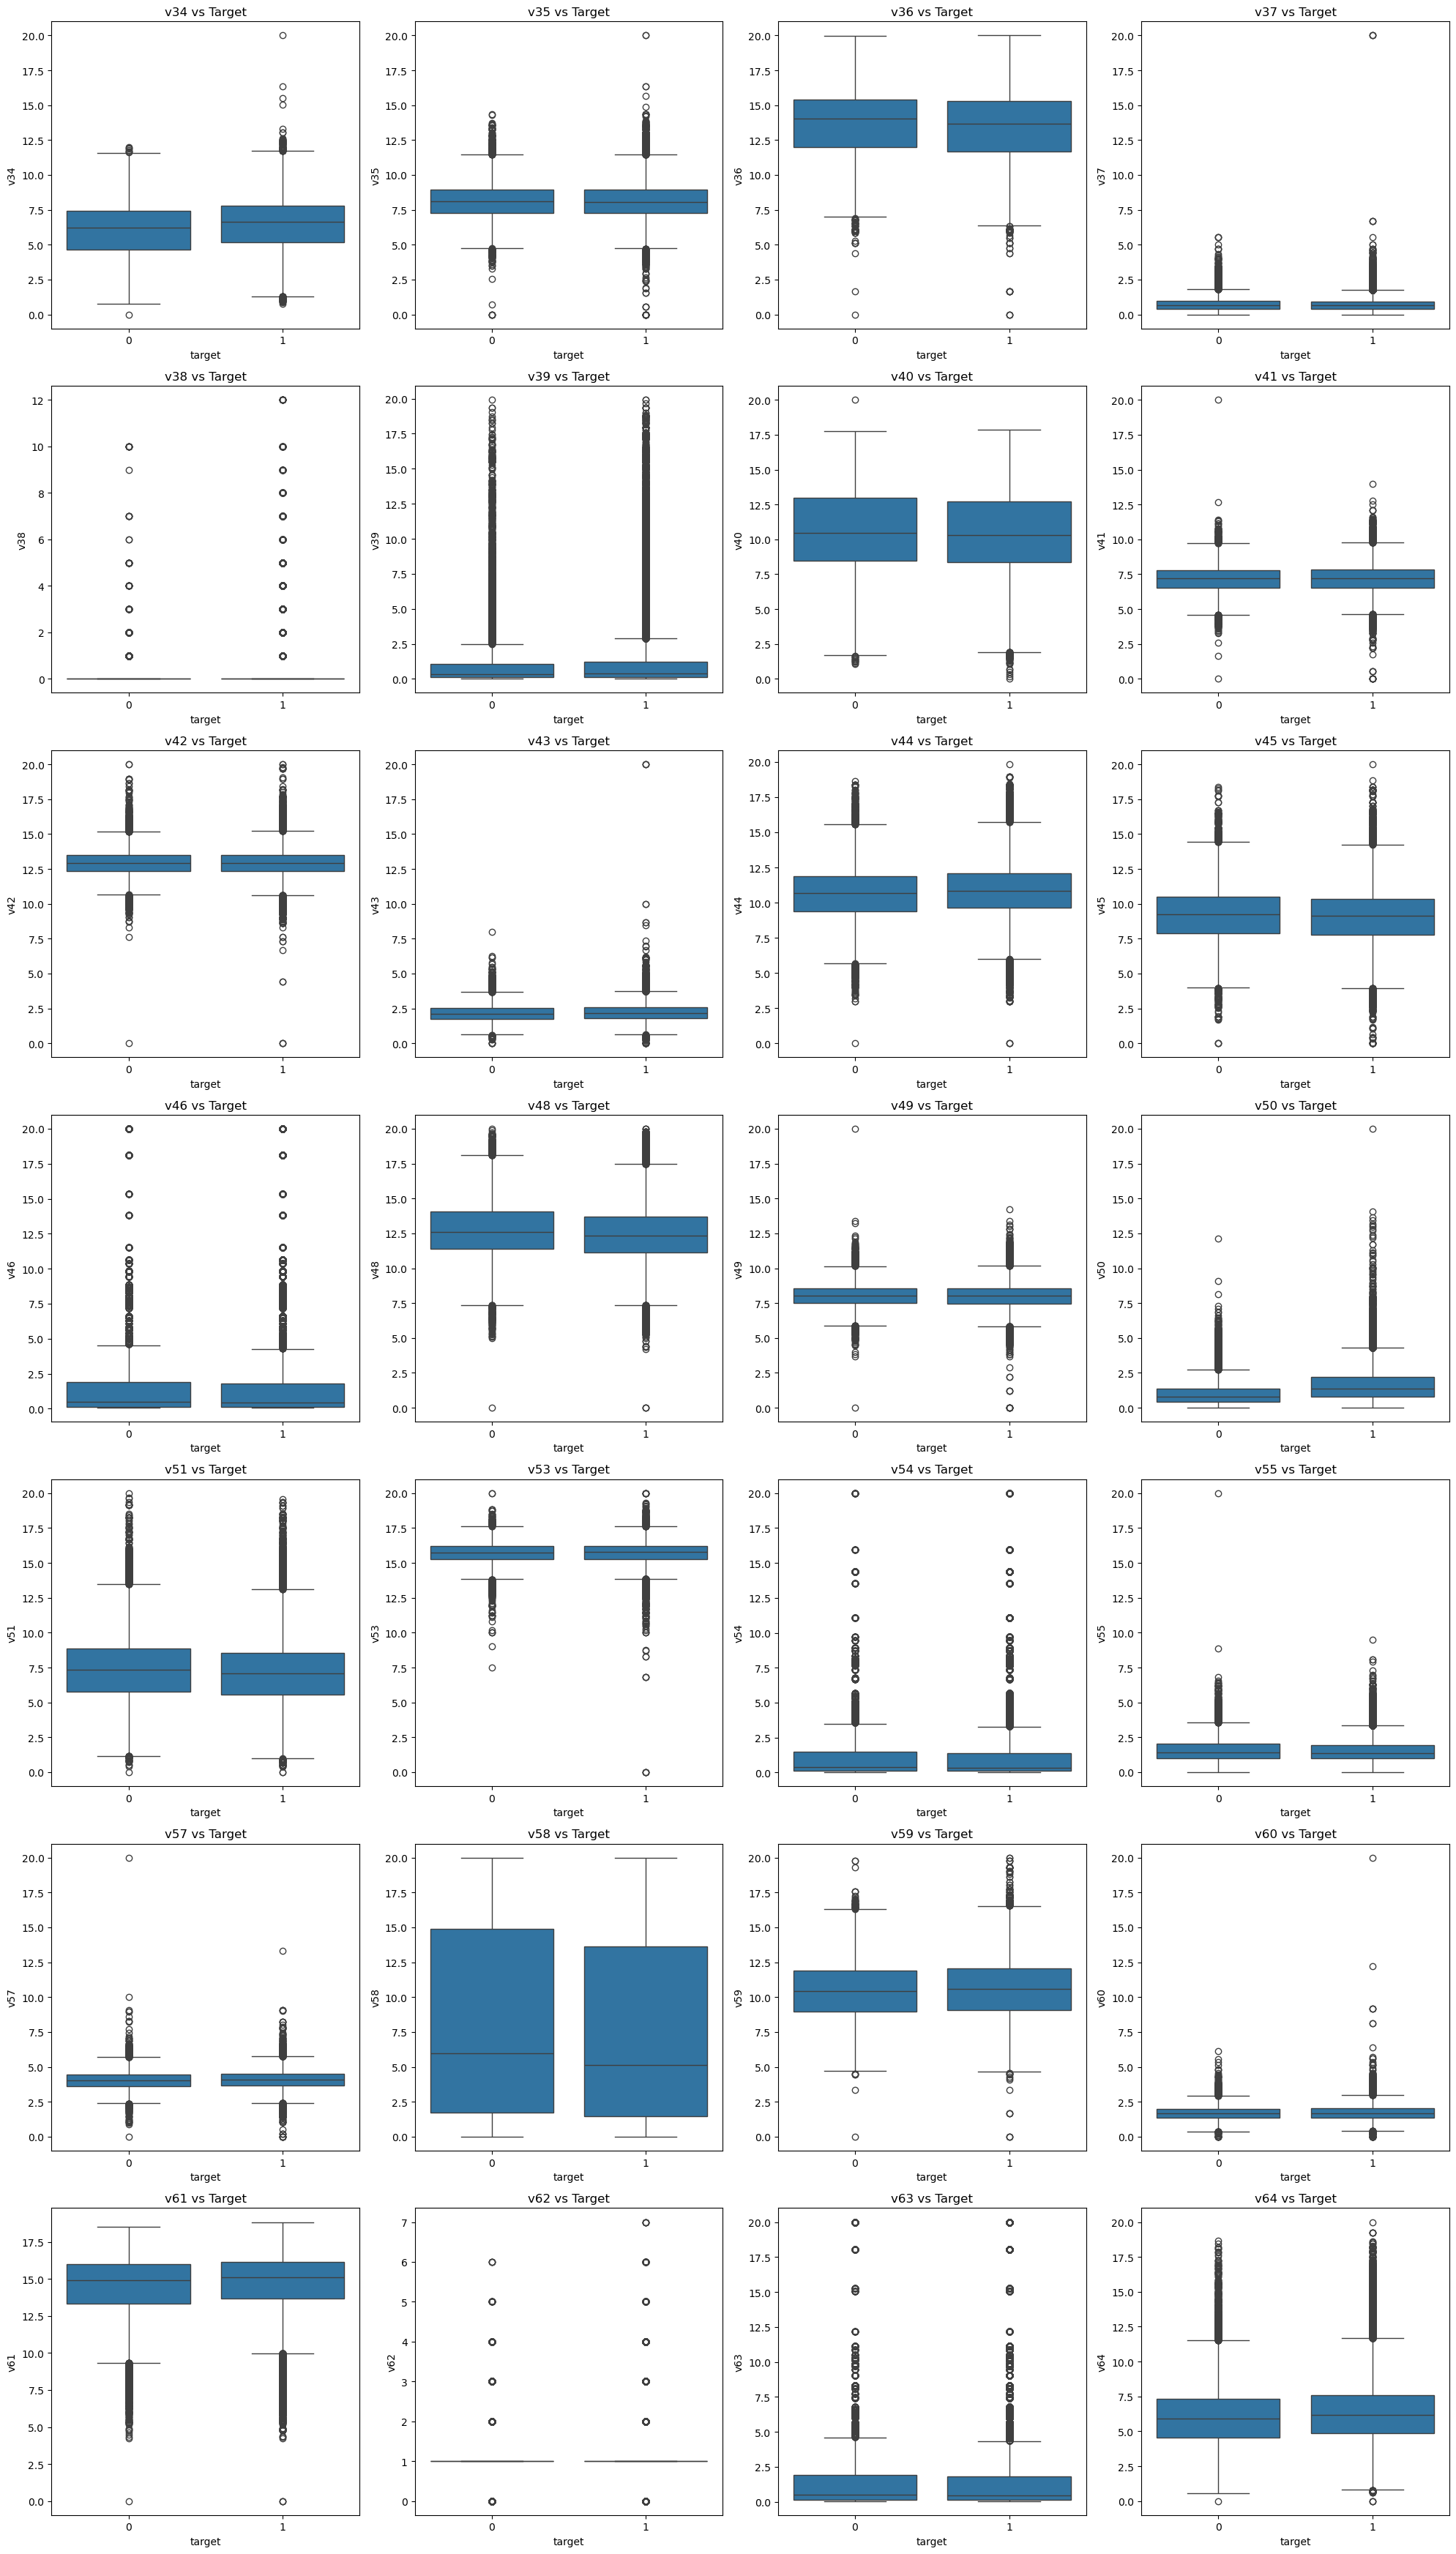

In [65]:
subset_cols = numerical_cols[28:56]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    try:
        sns.boxplot(x='target', y=col, data=df, ax=axes[i])
        axes[i].set_title(f'{col} vs Target')
    except Exception as e:
        print(f'Error plotting {col}: {e}')
        axes[i].text(0.5, 0.5, 'Error', ha='center', va='center')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v65
Processing feature 6/28: v72
Processing feature 11/28: v80
Processing feature 16/28: v85
Processing feature 21/28: v90
Processing feature 26/28: v96


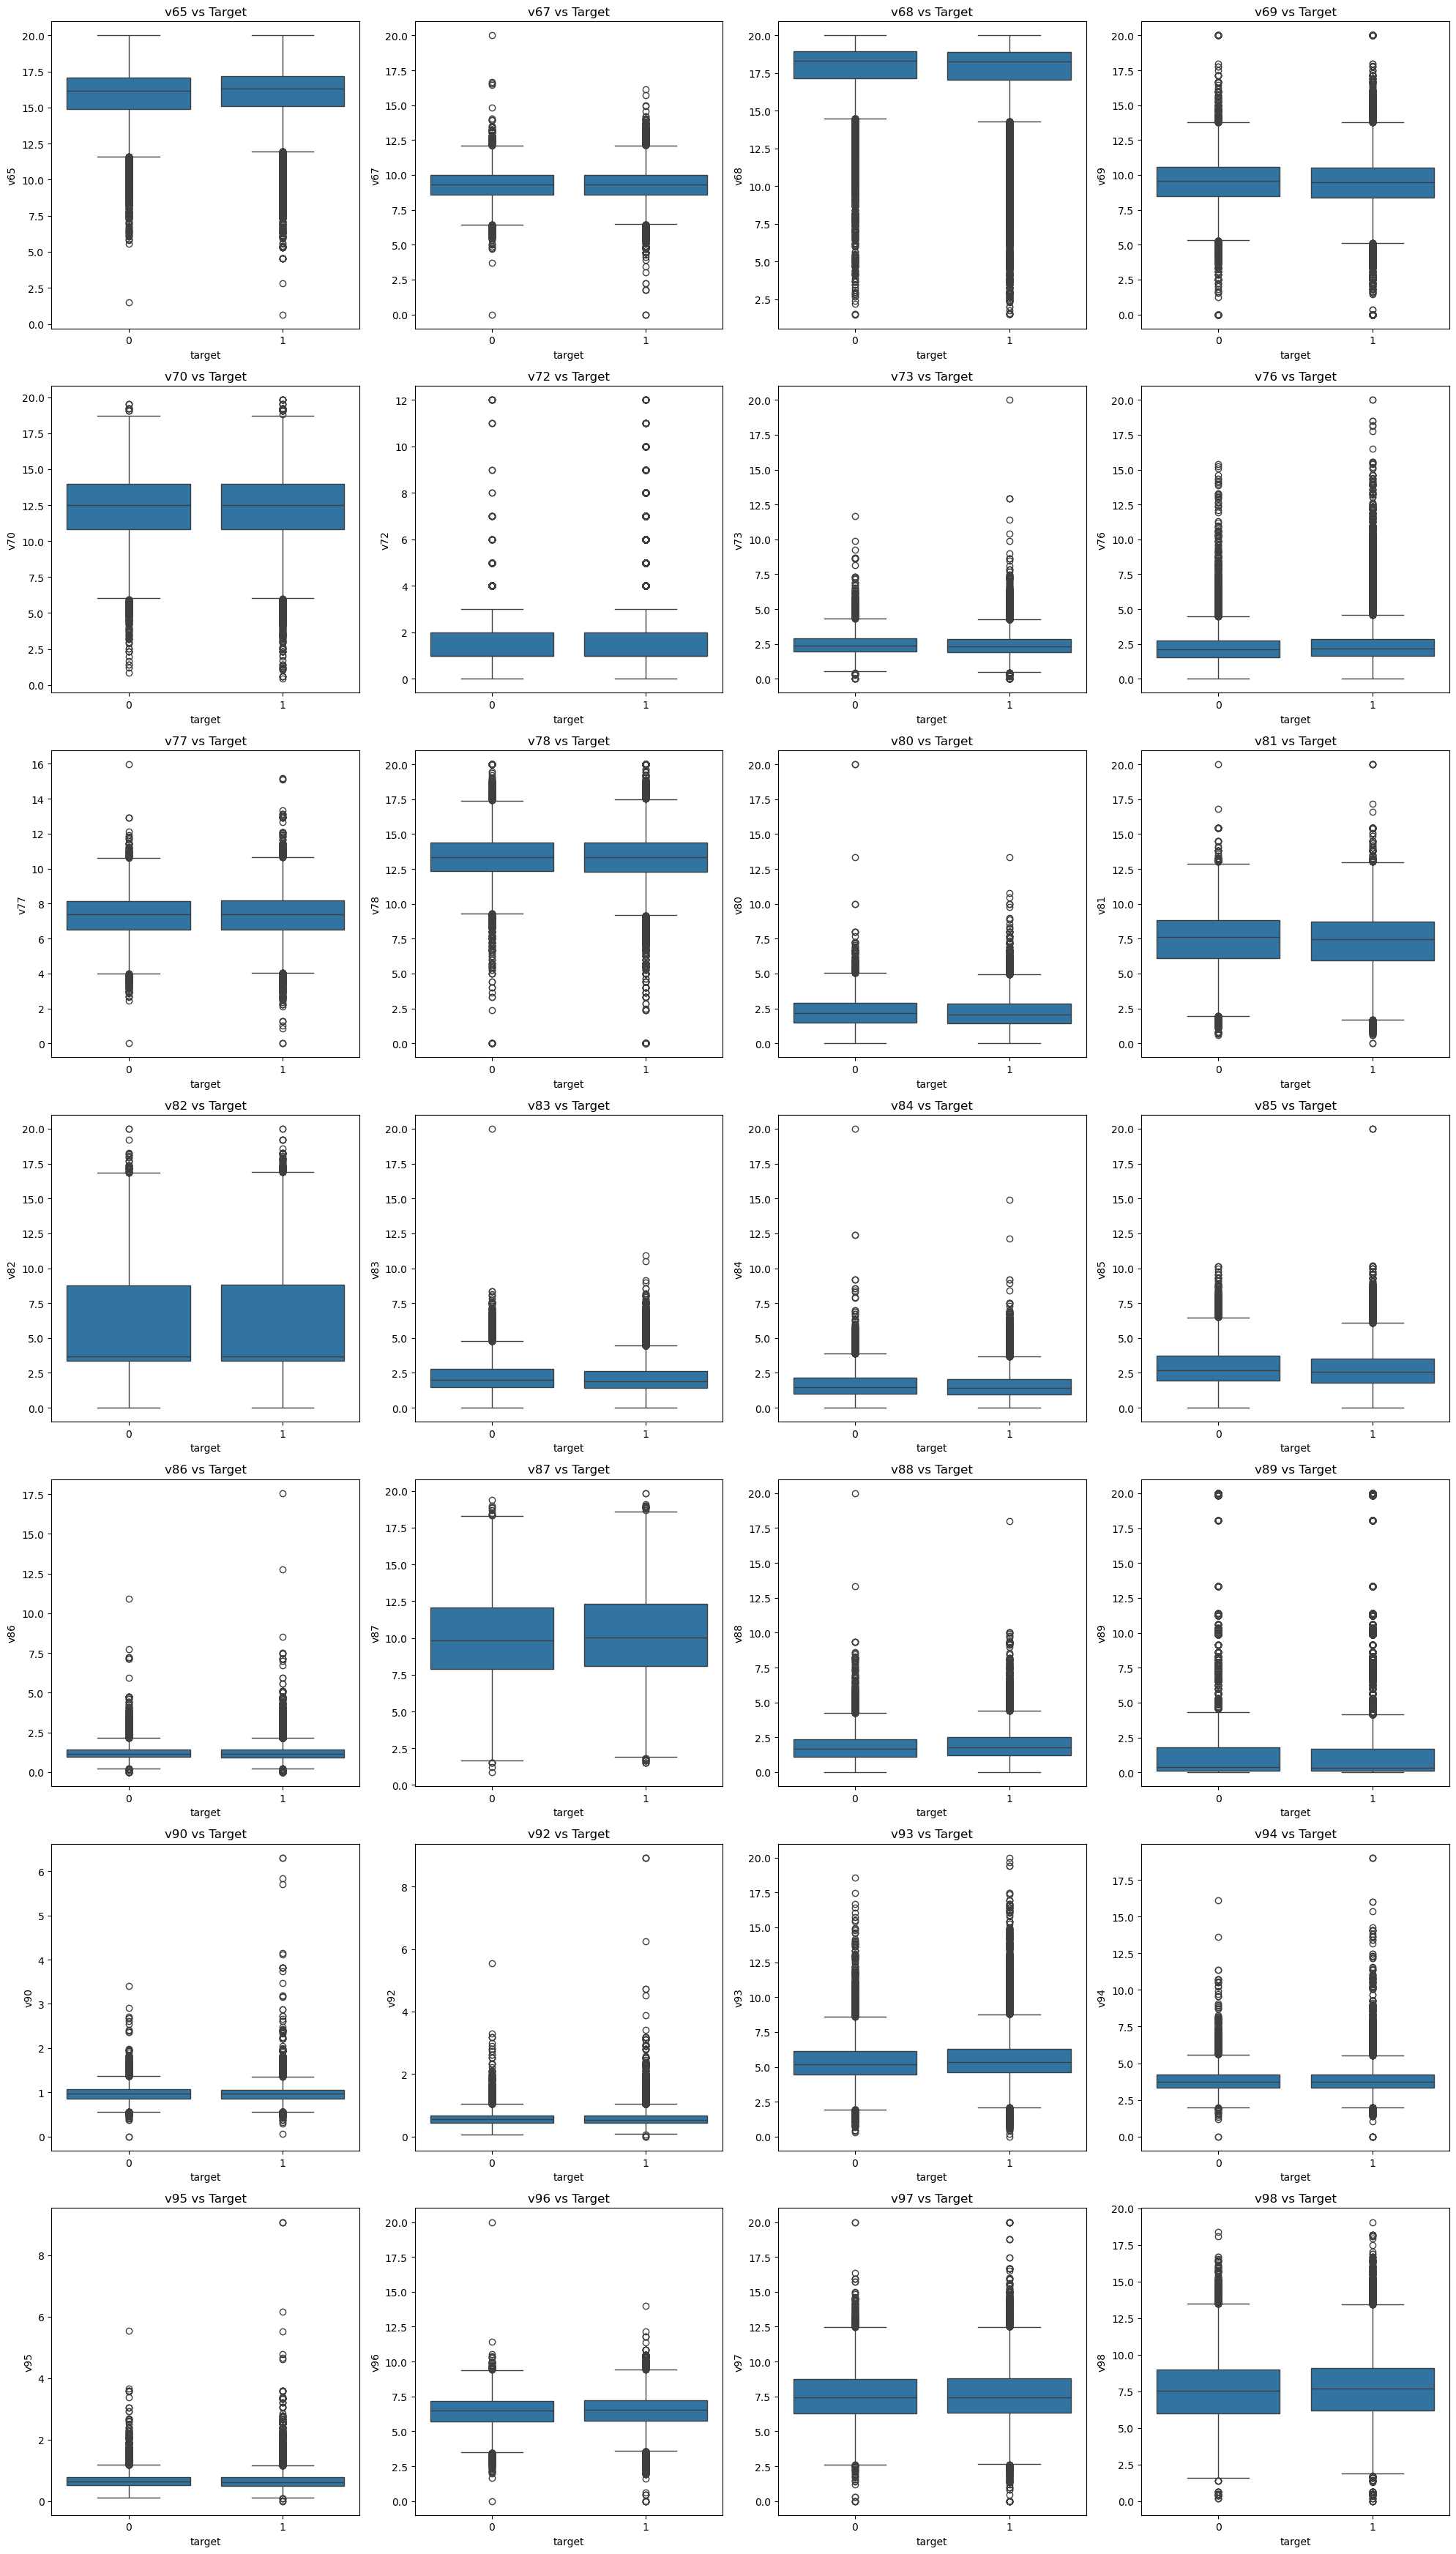

In [66]:
subset_cols = numerical_cols[56:84]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    try:
        sns.boxplot(x='target', y=col, data=df, ax=axes[i])
        axes[i].set_title(f'{col} vs Target')
    except Exception as e:
        print(f'Error plotting {col}: {e}')
        axes[i].text(0.5, 0.5, 'Error', ha='center', va='center')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Plotting 28 features...
Processing feature 1/28: v99
Processing feature 6/28: v104
Processing feature 11/28: v111
Processing feature 16/28: v118
Processing feature 21/28: v123
Processing feature 26/28: v129


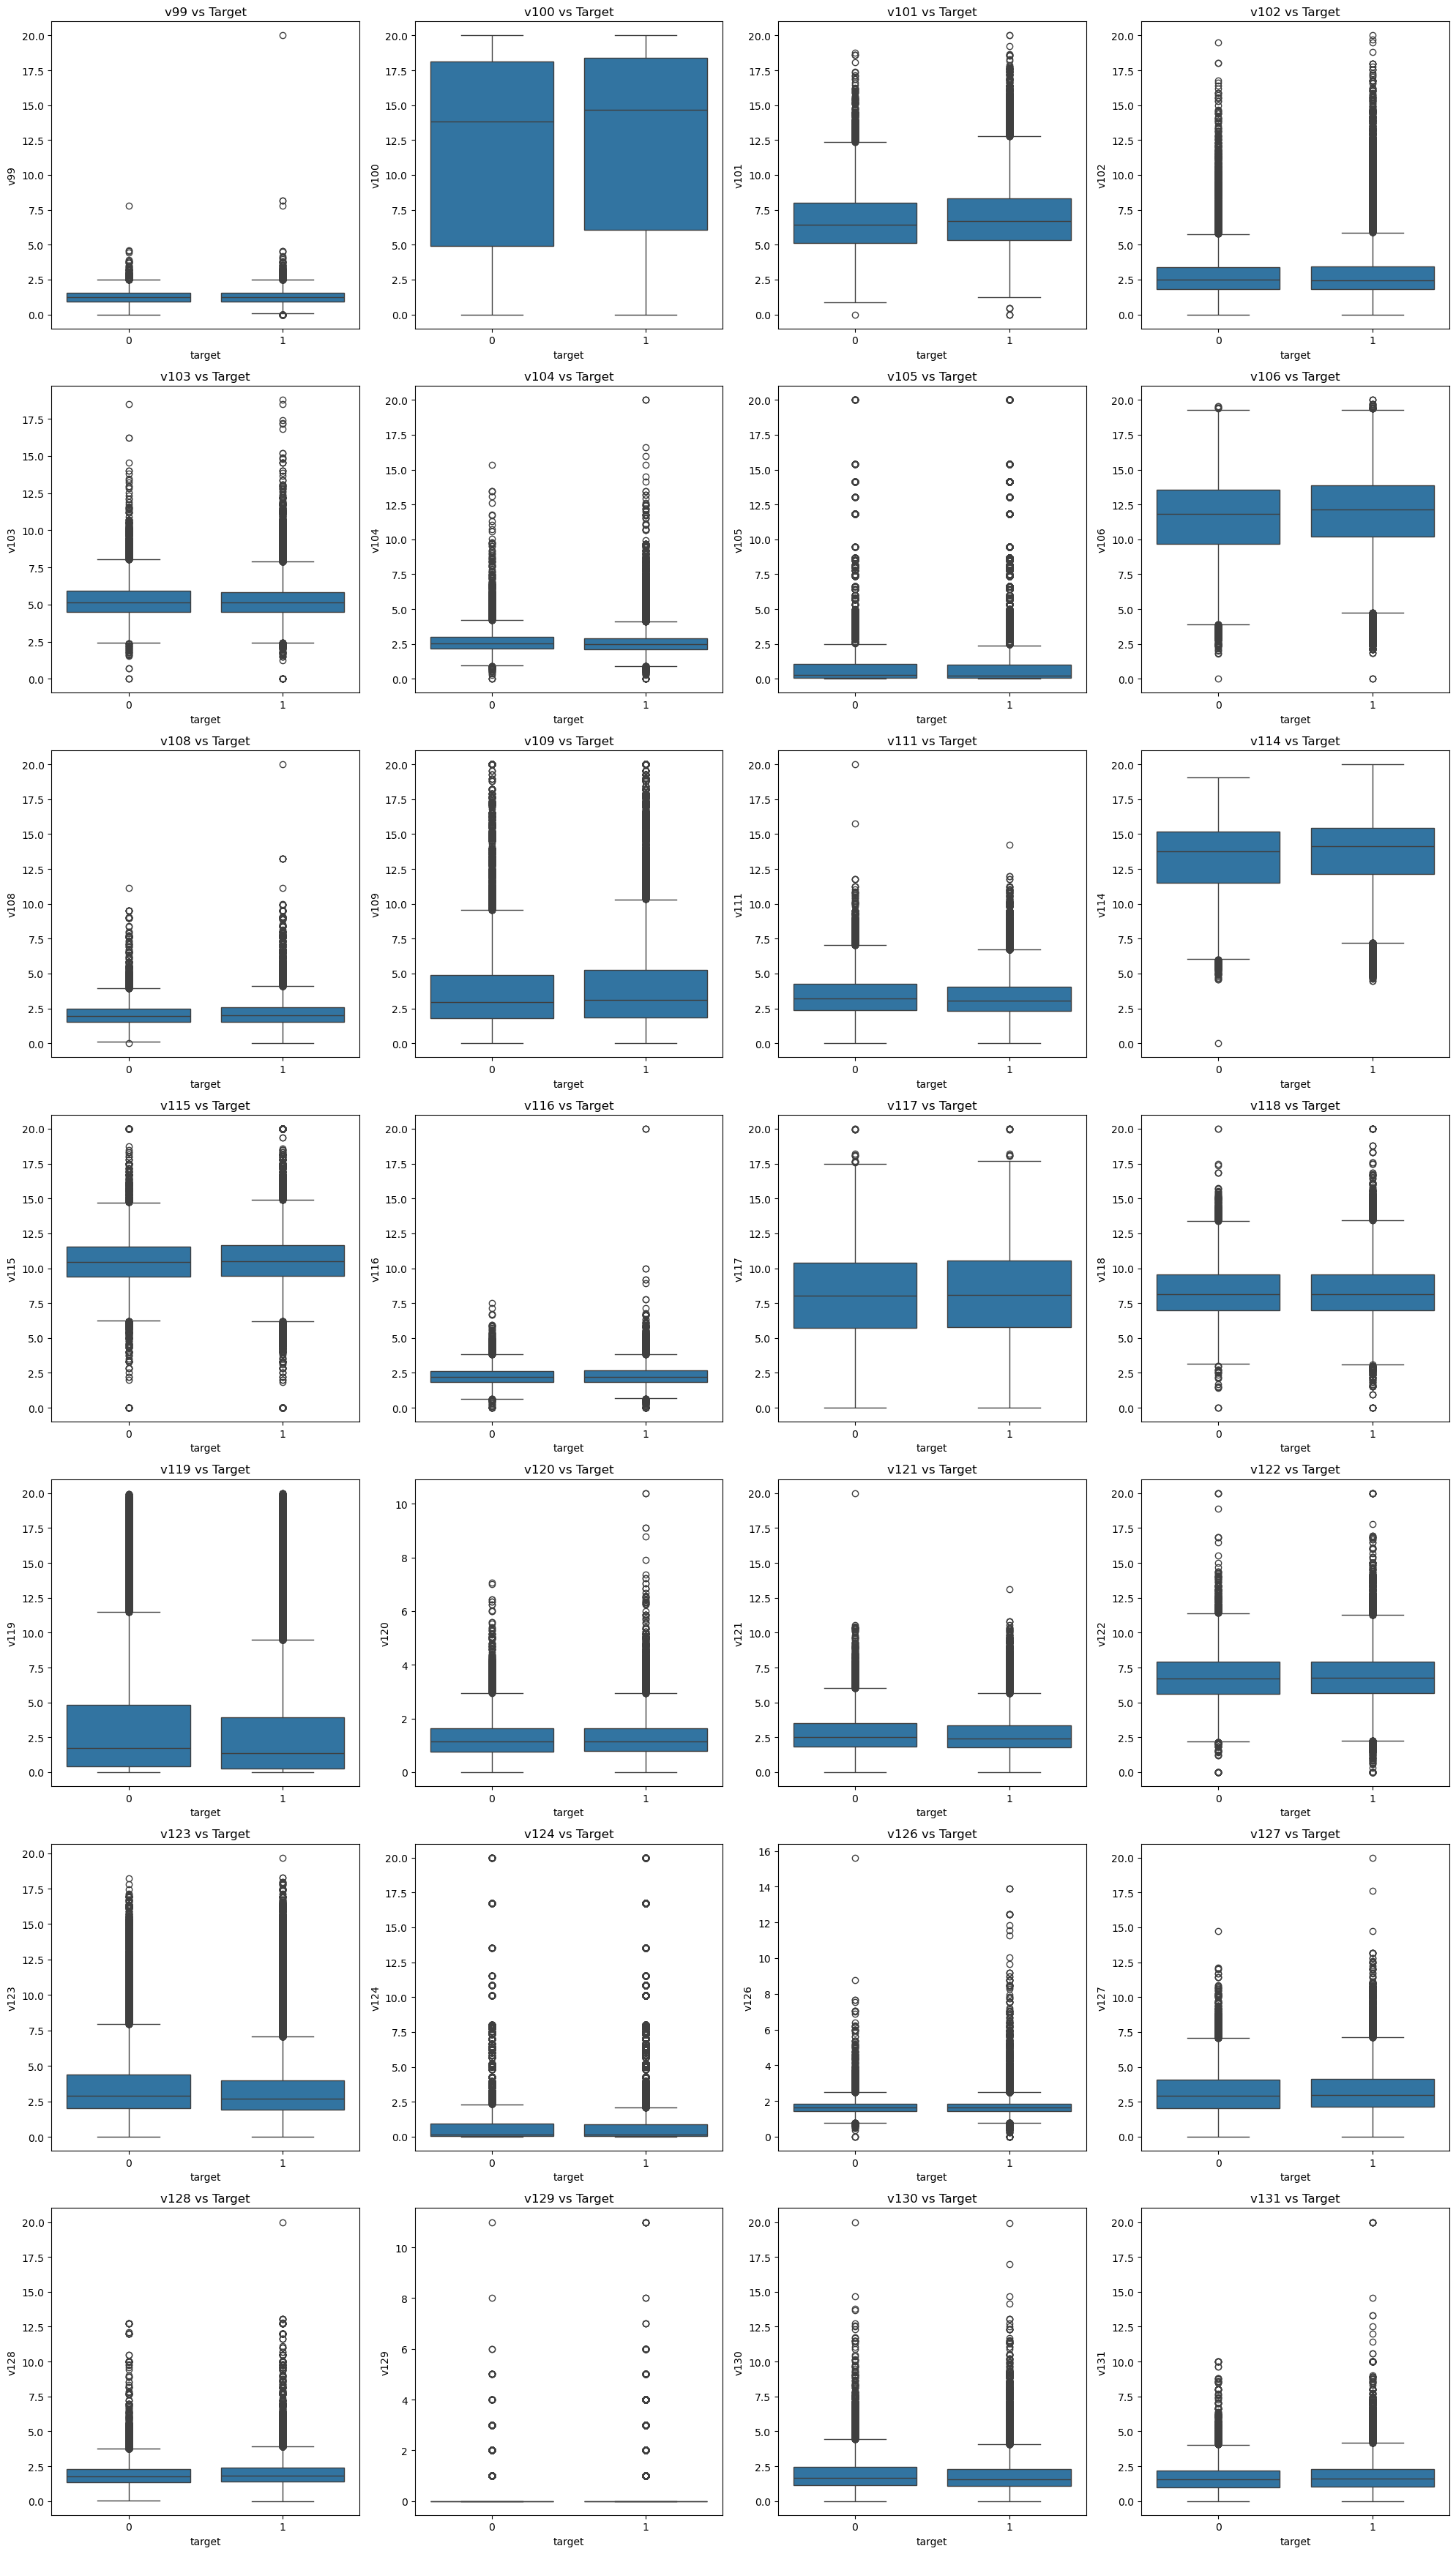

In [67]:
subset_cols = numerical_cols[84:112]
n_cols = 4
n_rows = math.ceil(len(subset_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

print(f'Plotting {len(subset_cols)} features...')
for i, col in enumerate(subset_cols):
    if i % 5 == 0: print(f'Processing feature {i+1}/{len(subset_cols)}: {col}')
    try:
        sns.boxplot(x='target', y=col, data=df, ax=axes[i])
        axes[i].set_title(f'{col} vs Target')
    except Exception as e:
        print(f'Error plotting {col}: {e}')
        axes[i].text(0.5, 0.5, 'Error', ha='center', va='center')

for i in range(len(subset_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

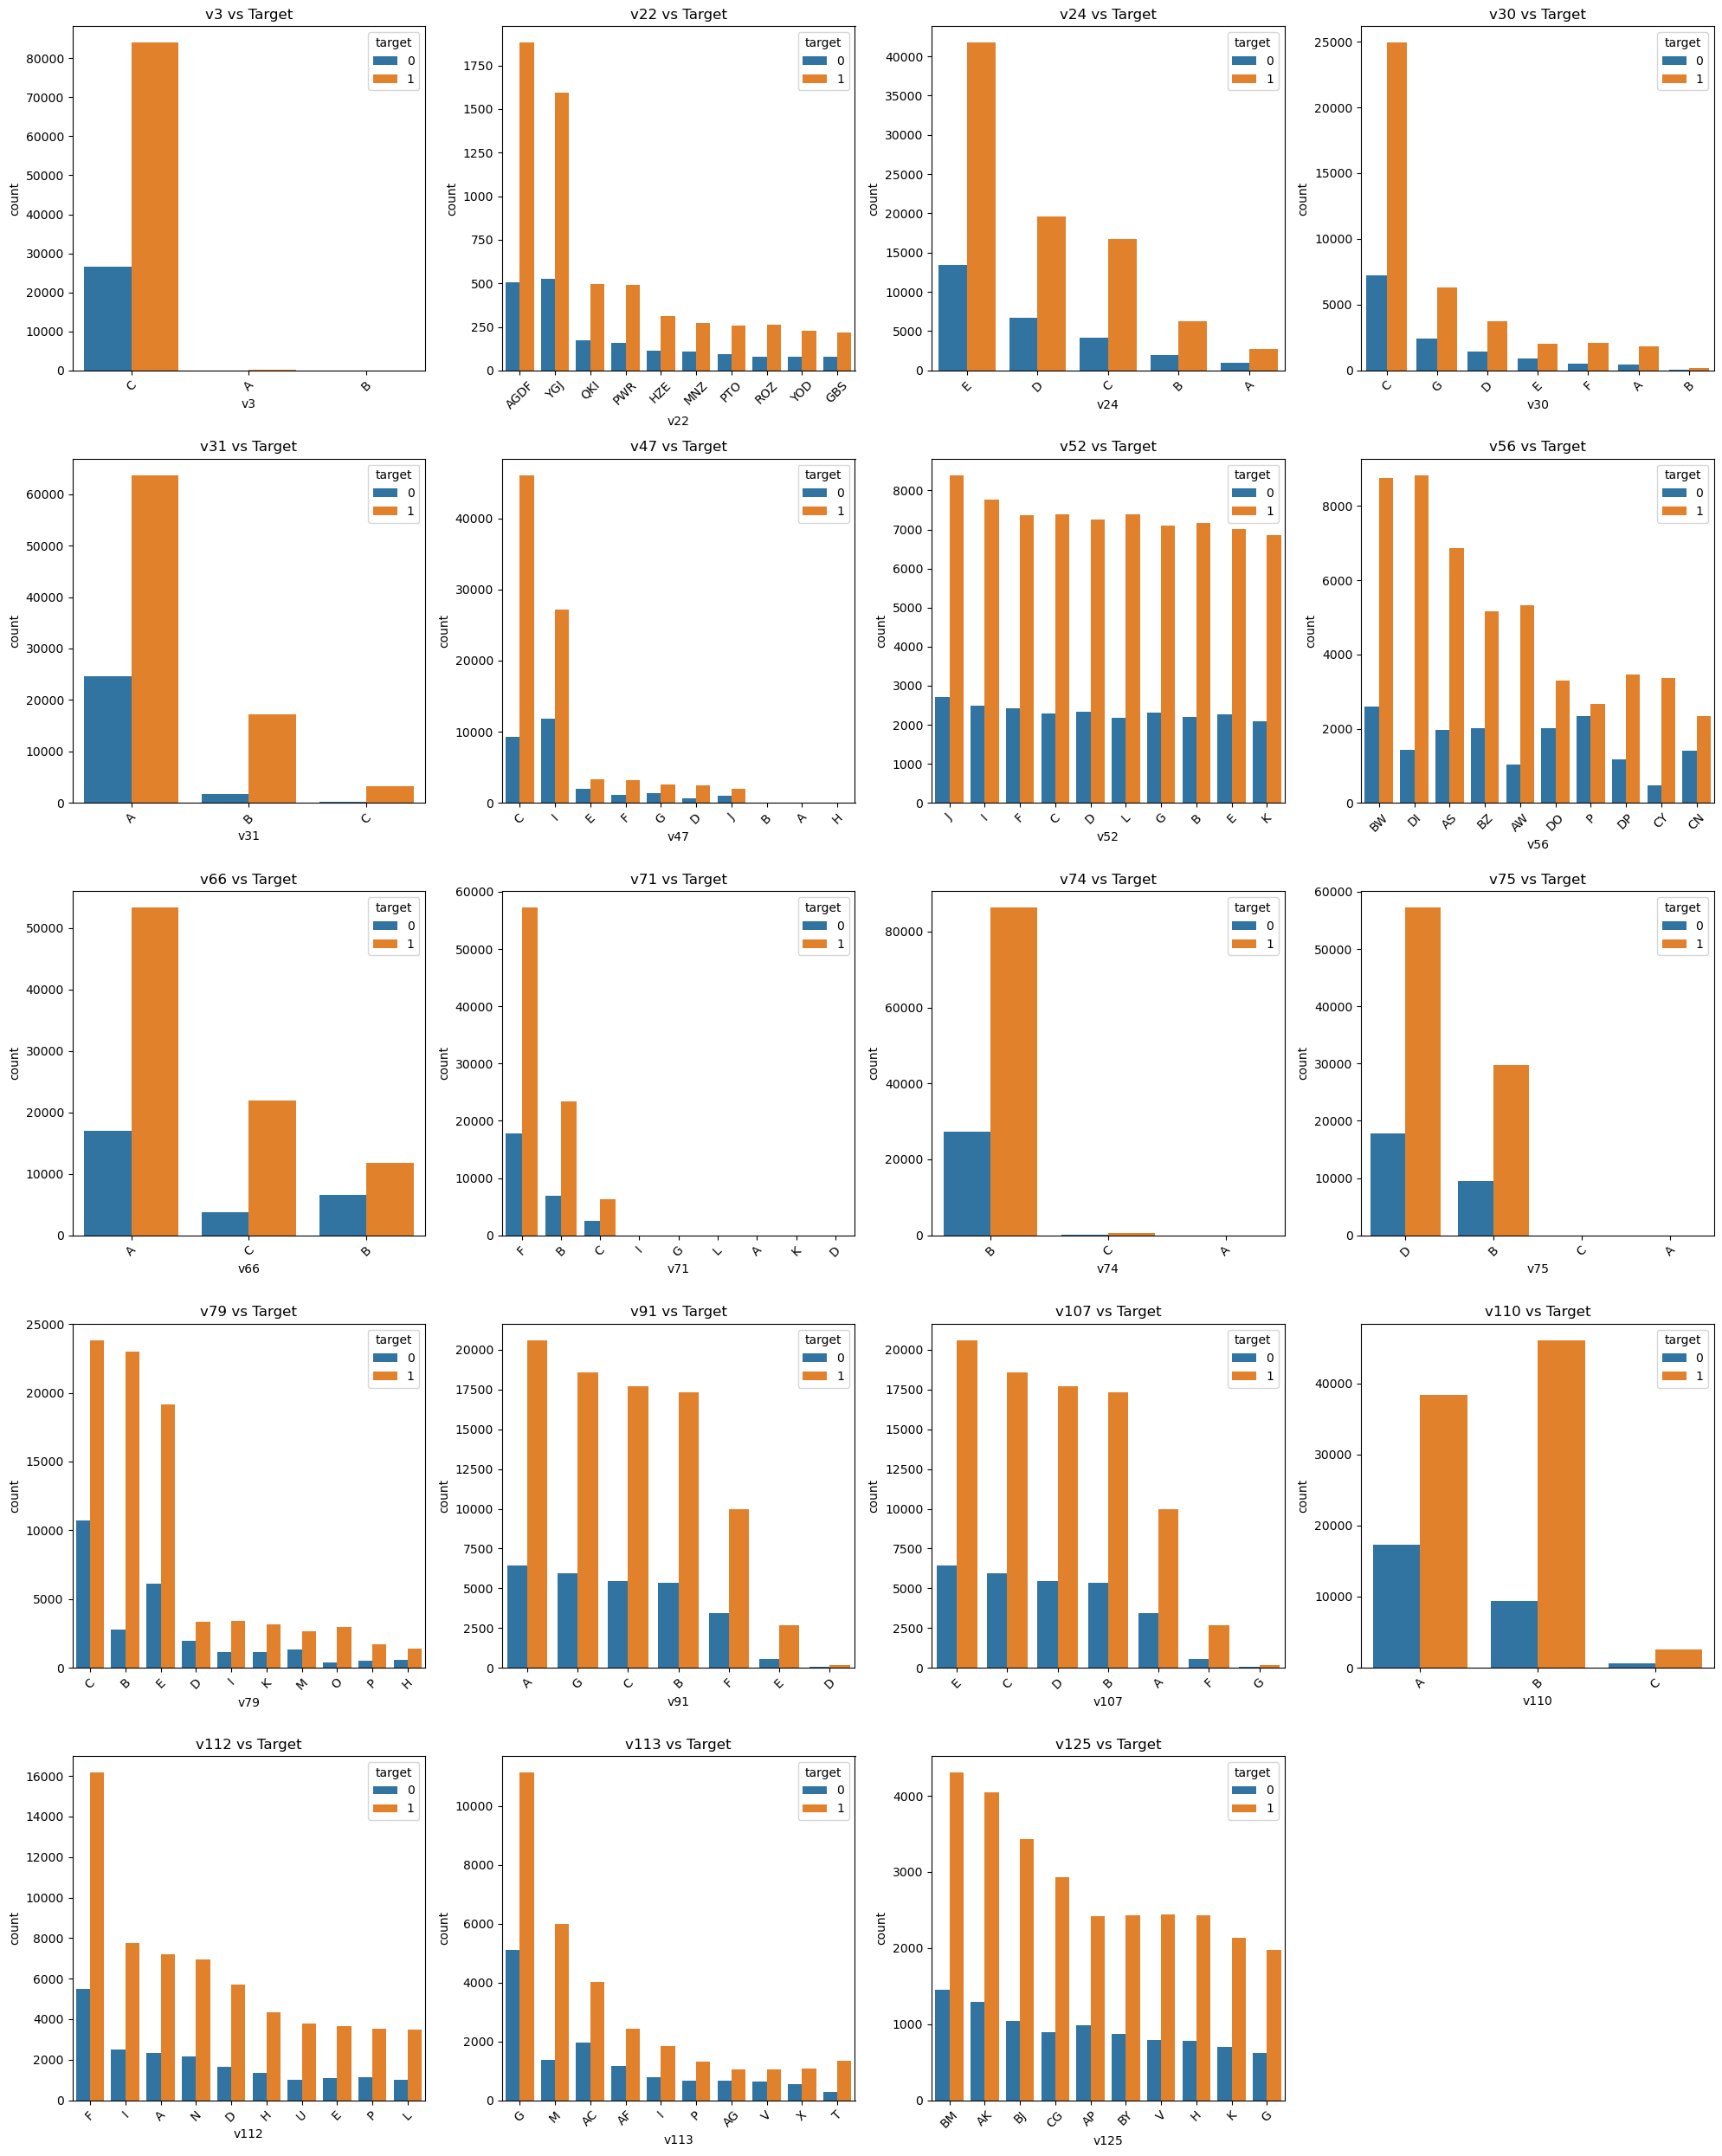

In [68]:
n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    top_cats = df[col].value_counts().index[:10]
    sns.countplot(x=col, hue='target', data=df[df[col].isin(top_cats)], ax=axes[i], order=top_cats)
    axes[i].set_title(f'{col} vs Target')
    axes[i].tick_params(axis='x', rotation=45)

for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

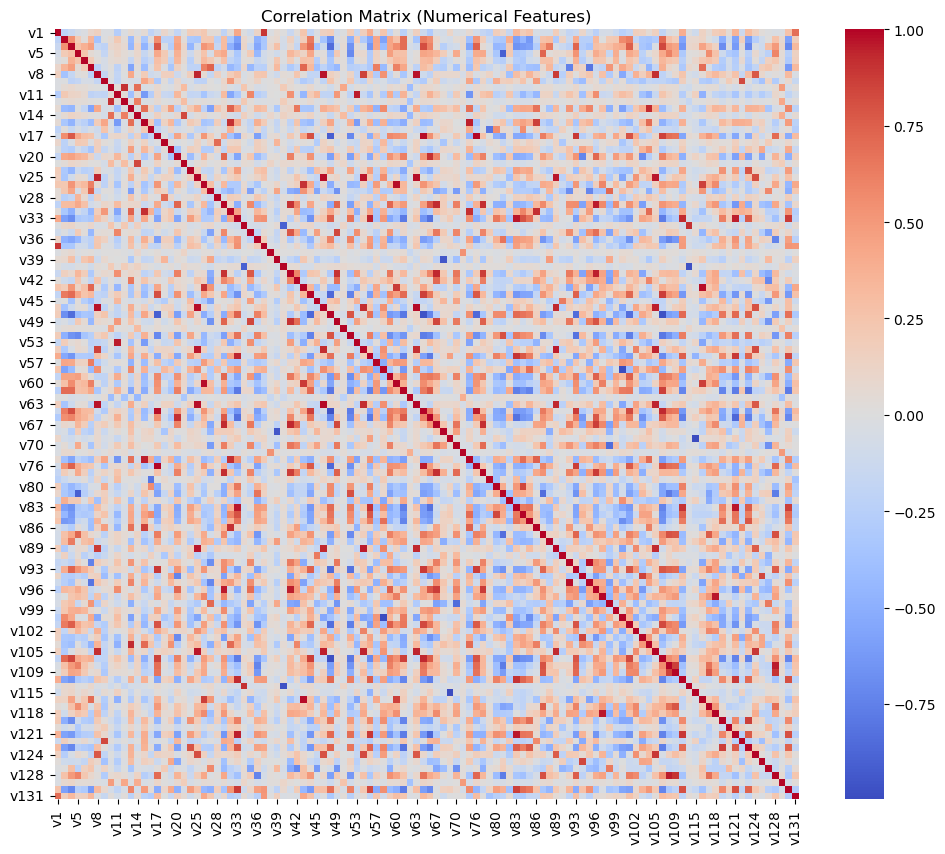

Top 10 absolute correlations:
v100  v58     0.997665
v69   v115    0.993691
v76   v17     0.992671
v46   v63     0.991609
v64   v17     0.982626
v25   v46     0.982215
v63   v25     0.981040
v60   v26     0.980747
v106  v48     0.980726
v116  v43     0.977874
dtype: float64


In [70]:
if len(numerical_cols) > 0:
    corr = df[numerical_cols].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix (Numerical Features)')
    plt.show()

    c = corr.abs().unstack().sort_values(ascending=False)
    c = c[c < 1] # Remove self-correlation
    print("Top 10 absolute correlations:")
    print(c.head(20)[::2]) # Skip duplicates

### Метрики модели:

- LogLoss — качество вероятностных предсказаний

- Precision — точность ускоренных претензий

- Recall — полнота найденных ускоряемых претензий

- PR-AUC — общее качество ранжирования

- Precision при высоком пороге уверенности (после построение PR-кривой)


In [71]:
print("Checking for duplicate columns...")

duplicates = []
for i in range(len(df.columns)):
    col1 = df.columns[i]
    for j in range(i + 1, len(df.columns)):
        col2 = df.columns[j]
        # Check if columns are identical (handling NaNs)
        if df[col1].equals(df[col2]):
            duplicates.append((col1, col2))

if len(duplicates) > 0:
    print(f"Found {len(duplicates)} duplicate column pairs:")
    for col1, col2 in duplicates:
        print(f"- {col1} is identical to {col2}")
else:
    print("No duplicate columns found.")

Checking for duplicate columns...
No duplicate columns found.


Preparing data for Feature Importance...


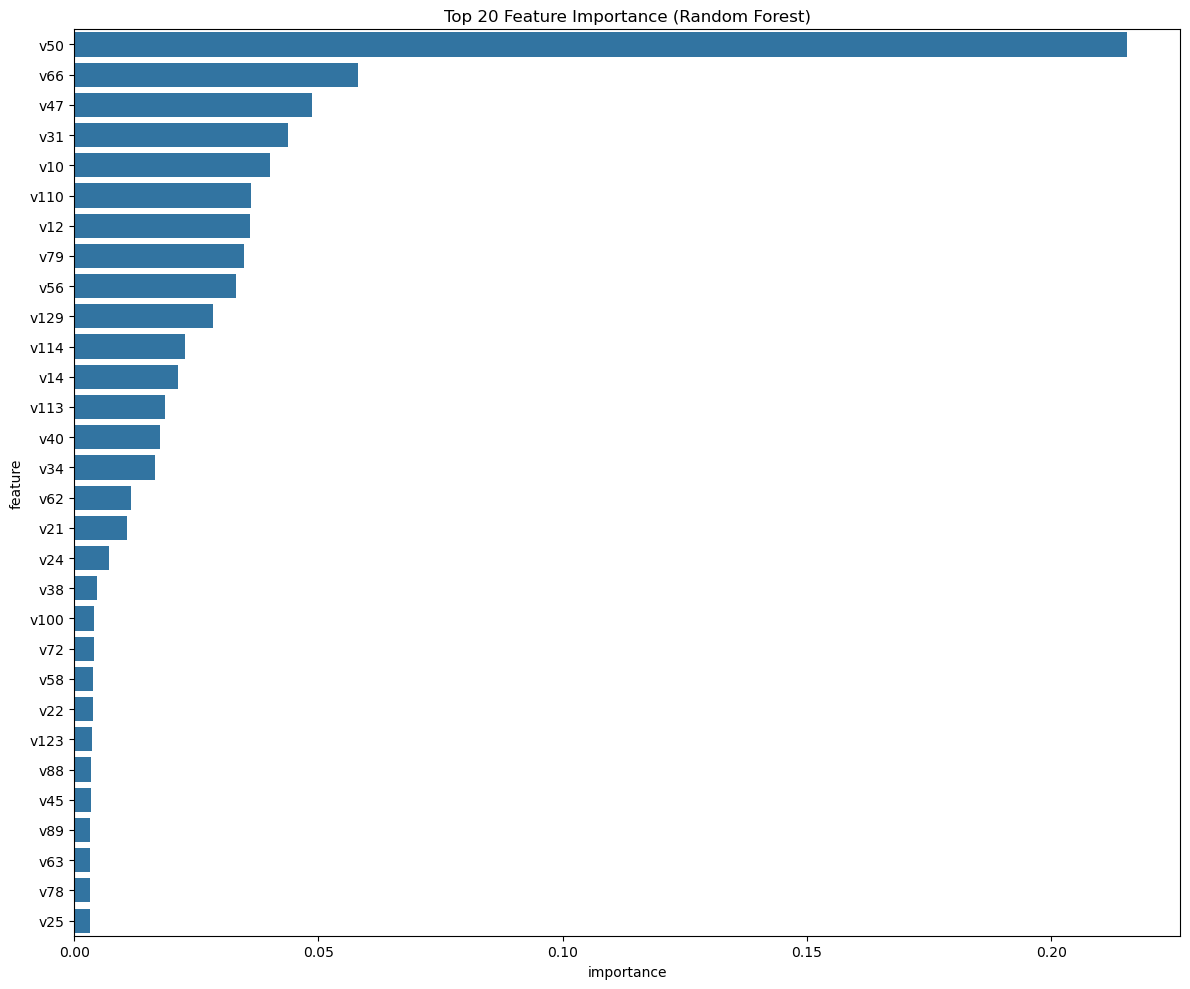

Top 20 Important Features:
    feature  importance
49      v50    0.215551
65      v66    0.058006
46      v47    0.048695
30      v31    0.043755
9       v10    0.040168
109    v110    0.036271
11      v12    0.036088
78      v79    0.034665
55      v56    0.033049
128    v129    0.028461
113    v114    0.022738
13      v14    0.021302
112    v113    0.018596
39      v40    0.017667
33      v34    0.016635
61      v62    0.011662
20      v21    0.010805
23      v24    0.007188
37      v38    0.004665
99     v100    0.004145


In [72]:
# Feature Importance using Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import math

print("Preparing data for Feature Importance...")

X = df.drop(['ID', 'target'], axis=1)
y = df['target']

# Handle categorical features
for col in categorical_cols:
    le = LabelEncoder()
    # Convert to string to handle mixed types/NaNs during encoding
    X[col] = le.fit_transform(X[col].astype(str))

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(30))
plt.title('Top 20 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("Top 20 Important Features:")
print(feature_importance_df.head(20))


Calculating Permutation Importance...


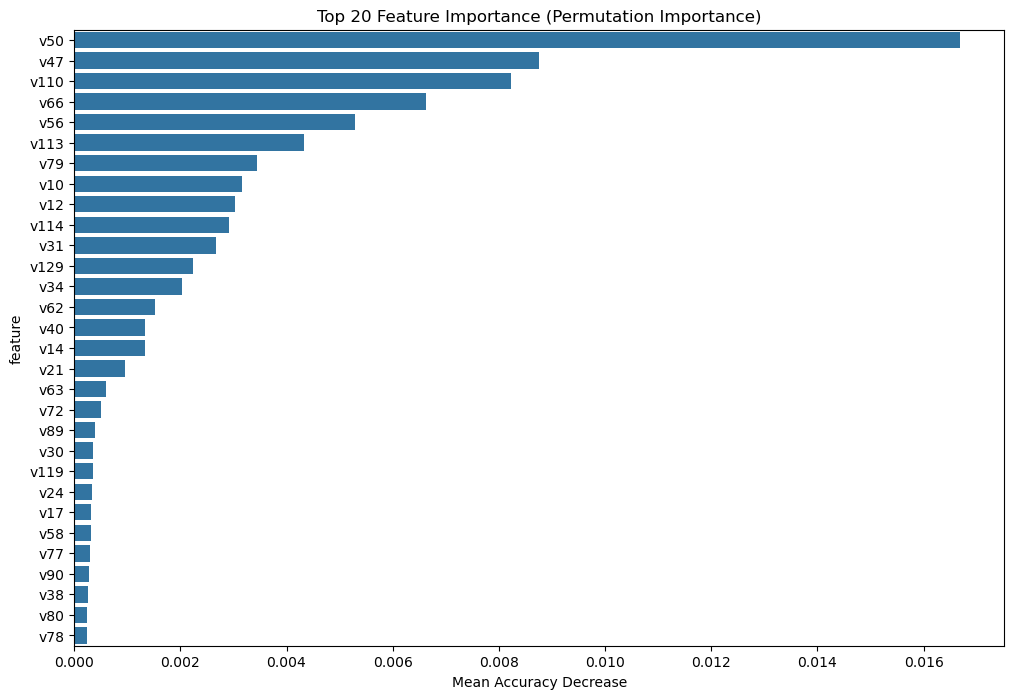

Top 20 Important Features (Permutation):
    feature  importance       std
49      v50    0.016683  0.000428
46      v47    0.008747  0.000309
109    v110    0.008235  0.000170
65      v66    0.006634  0.000281
55      v56    0.005299  0.000223
112    v113    0.004332  0.000219
78      v79    0.003452  0.000307
9       v10    0.003168  0.000209
11      v12    0.003023  0.000270
113    v114    0.002911  0.000137
30      v31    0.002675  0.000176
128    v129    0.002239  0.000135
33      v34    0.002035  0.000173
61      v62    0.001524  0.000101
39      v40    0.001333  0.000140
13      v14    0.001333  0.000080
20      v21    0.000959  0.000098
62      v63    0.000600  0.000135
71      v72    0.000507  0.000069
88      v89    0.000399  0.000115


In [73]:
# Permutation Importance
from sklearn.inspection import permutation_importance

print("Calculating Permutation Importance...")
result = permutation_importance(rf, X, y, n_repeats=5, random_state=42, n_jobs=-1)

perm_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': result.importances_mean,
    'std': result.importances_std
})
perm_importance_df = perm_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=perm_importance_df.head(30))
plt.title('Top 20 Feature Importance (Permutation Importance)')
plt.xlabel('Mean Accuracy Decrease')
plt.show()

print("Top 20 Important Features (Permutation):")
print(perm_importance_df.head(20))